In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
0                         0.0            16.093                  0.0   
1                         0.0            16.093    

In [3]:
max_visibility = CV_rows["HourlyVisibility"].max()
min_visibility = CV_rows["HourlyVisibility"].min()
print("Maximum HourlyVisibility:", max_visibility)
print("Minimum HourlyVisibility:", min_visibility)

Maximum HourlyVisibility: 16.093
Minimum HourlyVisibility: 0.0


In [4]:
# remove rows where HourlyVisibility is zero or missing
# CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
# CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10821802, 14)


In [5]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10429072, 14)


In [6]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_fog_rows = CV_fog_rows[~CV_fog_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_fog_rows after removing April-October:", CV_fog_rows.shape)

CV_fog_rows after removing April-October: (4526168, 14)


In [7]:
# mask = CV_rows["HourlyVisibility"].gt(16) & CV_rows["HourlyVisibility"].lt(17)
# vis_between_16_17 = CV_rows.loc[mask, "HourlyVisibility"]

# print("Count:", len(vis_between_16_17))
# print("Unique visibility values between 16 and 17 km:")
# print(sorted(vis_between_16_17.unique()))

# print("\nSample rows:")
# print(vis_between_16_17.head(50).to_string(index=False))

In [8]:
# # Cap visibilities over 16.093 km to 16.093 km in CV_fog_rows
# CV_fog_rows['HourlyVisibility'] = CV_fog_rows['HourlyVisibility'].clip(upper=16.093)

# print("CV_fog_rows after capping visibility at 16.093 km:")
# print(f"Max visibility: {CV_fog_rows['HourlyVisibility'].max()}")
# print(f"Min visibility: {CV_fog_rows['HourlyVisibility'].min()}")

In [9]:
CV_fog_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,0.0,16.093,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,0.0,16.093,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,0.0,16.093,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,0.0,16.093,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,0.0,16.093,225.0,0.5,1941,12,1,4,0,GARDNER AAF


In [10]:
# Build fog events from hourly fog rows and count "fog days" with noon-crossing adjustment
fog_events = CV_fog_rows.loc[:, ["STATION", "DATE"]].copy()
fog_events["DATE"] = pd.to_datetime(fog_events["DATE"], errors="coerce")
fog_events = fog_events.dropna(subset=["DATE"]).sort_values(["STATION", "DATE"])

# New event starts when time gap within station is > 1.5 hours (or first record)
gap = fog_events.groupby("STATION")["DATE"].diff()
fog_events["new_event"] = gap.isna() | gap.gt(pd.Timedelta(hours=2))
fog_events["event_id"] = fog_events.groupby("STATION")["new_event"].cumsum()

# Event start/end per station-event
event_summary = (
    fog_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(start=("DATE", "min"), end=("DATE", "max"))
)

event_summary["start_date"] = event_summary["start"].dt.floor("D")
event_summary["end_date"] = event_summary["end"].dt.floor("D")
event_summary["calendar_days"] = (event_summary["end_date"] - event_summary["start_date"]).dt.days + 1

# Rule:
# - If event starts after noon and continues into next calendar day, count that first overnight span as 1 day
adjust_first_overnight = (
    (event_summary["start"].dt.hour > 12) &
    (event_summary["end_date"] > event_summary["start_date"])
).astype(int)

event_summary["counted_days"] = (event_summary["calendar_days"] - adjust_first_overnight).clip(lower=1).astype(int)

# Expand each event into counted day labels, then aggregate by station-year
expanded = event_summary.loc[event_summary.index.repeat(event_summary["counted_days"])].copy()
expanded["day_offset"] = expanded.groupby(level=0).cumcount()
expanded["fog_day"] = expanded["start_date"] + pd.to_timedelta(expanded["day_offset"], unit="D")
expanded["year"] = expanded["fog_day"].dt.year

fog_days_year_noon_rule = (
    expanded
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

print(fog_days_year_noon_rule.head())
print("Rows:", fog_days_year_noon_rule.shape)

          STATION  year  fog_days
0  BAKERSFIELD AP  1928       168
1  BAKERSFIELD AP  1929       250
2  BAKERSFIELD AP  1930        94
3  BAKERSFIELD AP  1931       118
4  BAKERSFIELD AP  1932       153
Rows: (1278, 3)


In [11]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        66
1  BAKERSFIELD AP  1929       120
2  BAKERSFIELD AP  1930        80
3  BAKERSFIELD AP  1931       108
4  BAKERSFIELD AP  1932       152


In [12]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


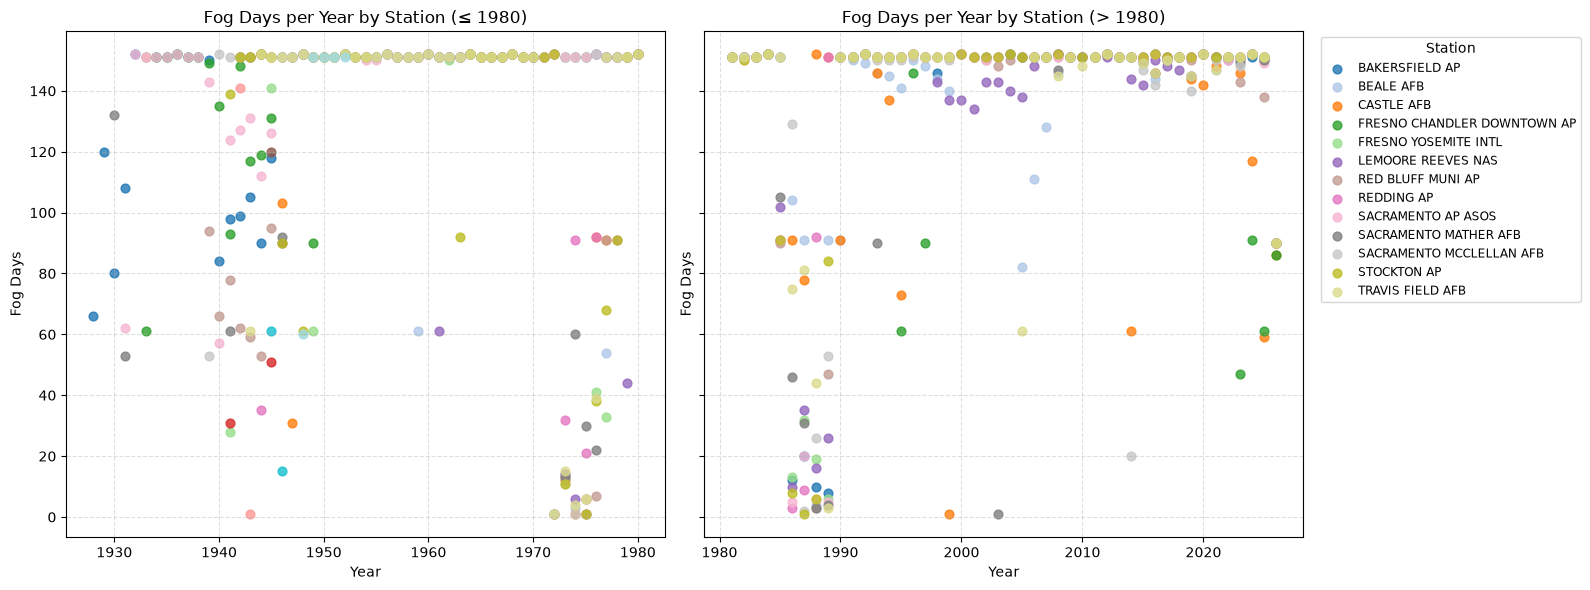

In [13]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

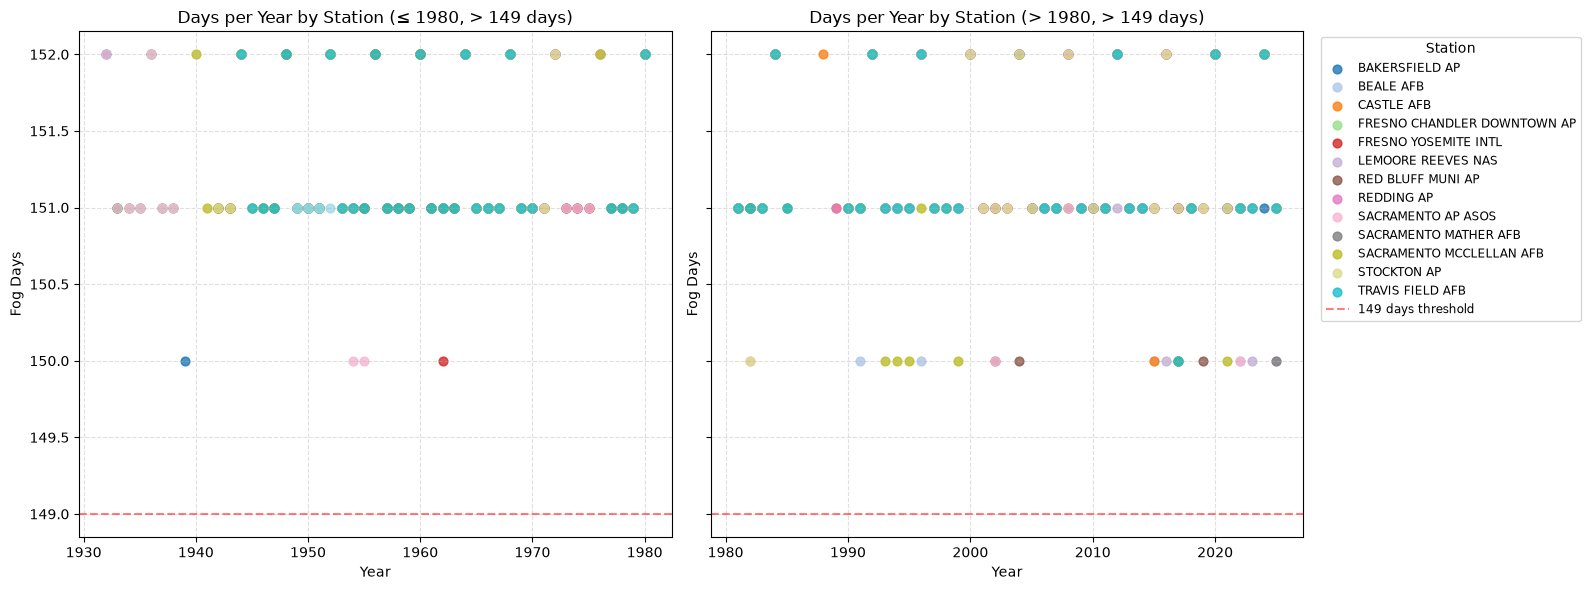

Stations with > 149 days: 16
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [28]:
# Remove stations with less than or only 200 days counted
fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] > 149]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 355 fog days
fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 149 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 149 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 149 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [29]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 150].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 918
CV_fog_rows_no_outliers: (3630671, 14)


In [16]:
# # Evaluate fog-day trends for increasing visibility thresholds (1 to 25 km)
# # using the already-filtered CV_fog_rows_no_outliers dataframe.

# p_cutoff = 0.05
# thresholds = list(range(1, 26))

# annual_by_threshold = {}
# trend_rows = []

# for threshold in thresholds:
#     # Keep rows with visibility below the current threshold
#     threshold_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < threshold].copy()

#     # Count unique fog days per station-year (avoid double-counting same day)
#     annual = (
#         threshold_df
#         .drop_duplicates(subset=["STATION", "year", "month", "day"])
#         .groupby(["STATION", "year"], as_index=False)
#         .size()
#         .rename(columns={"size": "fog_days"})
#         .sort_values(["STATION", "year"])
#     )
#     annual_by_threshold[threshold] = annual

#     # Fit a simple linear trend for each station
#     for station, station_df in annual.groupby("STATION", sort=False):
#         station_df = station_df.sort_values("year")
#         if len(station_df) < 3:
#             continue

#         model = smf.ols("fog_days ~ year", data=station_df).fit()
#         p_value = float(model.pvalues["year"])

#         if np.isnan(p_value):
#             continue

#         trend_rows.append({
#             "threshold_km": threshold,
#             "STATION": station,
#             "n_obs": len(station_df),
#             "min_year": int(station_df["year"].min()),
#             "max_year": int(station_df["year"].max()),
#             "slope": float(model.params["year"]),
#             "intercept": float(model.params["Intercept"]),
#             "r_squared": float(model.rsquared),
#             "p_value": p_value,
#             "trend_significant": p_value < p_cutoff,
#         })

# threshold_trends = pd.DataFrame(trend_rows).sort_values(["threshold_km", "p_value"])
# significant_threshold_trends = threshold_trends[threshold_trends["trend_significant"]].copy()

# print("Significant threshold-based fog-day trends (p < 0.05):")
# print(
#     significant_threshold_trends[
#         ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
#     ].sort_values(["threshold_km", "p_value"]).to_string(index=False)
# )

# # Plot the significant trendlines by threshold
# if not significant_threshold_trends.empty:
#     thresholds_with_significant = sorted(significant_threshold_trends["threshold_km"].unique())

#     fig, axes = plt.subplots(
#         len(thresholds_with_significant),
#         1,
#         figsize=(16, 2.8 * len(thresholds_with_significant)),
#         sharex=True
#     )

#     if len(thresholds_with_significant) == 1:
#         axes = [axes]

#     for ax, threshold in zip(axes, thresholds_with_significant):
#         th_df = significant_threshold_trends[significant_threshold_trends["threshold_km"] == threshold].copy()
#         ax.set_title(f"Visibility threshold < {threshold} km (significant trends, p < 0.05)")

#         stations_for_threshold = th_df["STATION"].unique()
#         colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
#         color_map = dict(zip(stations_for_threshold, colors))

#         for station in stations_for_threshold:
#             row = th_df[th_df["STATION"] == station].iloc[0]
#             station_df = annual_by_threshold[threshold][
#                 annual_by_threshold[threshold]["STATION"] == station
#             ].sort_values("year")

#             if station_df.empty:
#                 continue

#             color = color_map[station]

#             # Observed annual fog days
#             ax.scatter(
#                 station_df["year"],
#                 station_df["fog_days"],
#                 s=20,
#                 color=color,
#                 alpha=0.8
#             )

#             # Fitted trend line
#             x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
#             y_hat = row["intercept"] + row["slope"] * x
#             ax.plot(x, y_hat, color=color, linewidth=1.5, label=station)

#         ax.set_ylabel("Fog days / year")
#         ax.grid(True, linestyle="--", alpha=0.4)
#         ax.legend(fontsize="small", loc="best")

#     axes[-1].set_xlabel("Year")
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No significant trends were found at the selected p-value threshold.")

In [37]:
# Evaluate fog-day trends by visibility threshold for years >= 1980
p_cutoff = 0.05
thresholds = list(range(1, 26))

df_1980 = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

annual_by_threshold_1980 = {}
trend_rows_1980 = []

for threshold in thresholds:
    th_df = df_1980[df_1980["HourlyVisibility"] < threshold].copy()
    annual = (
        th_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )
    annual_by_threshold_1980[threshold] = annual

    for station, station_df in annual.groupby("STATION", sort=False):
        station_df = station_df.sort_values("year")
        if len(station_df) < 3:
            continue
        model = smf.ols("fog_days ~ year", data=station_df).fit()
        p_value = float(model.pvalues.get("year", np.nan))
        if np.isnan(p_value):
            continue
        trend_rows_1980.append({
            "threshold_km": threshold,
            "STATION": station,
            "n_obs": len(station_df),
            "min_year": int(station_df["year"].min()),
            "max_year": int(station_df["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": p_value,
            "trend_significant": p_value < p_cutoff,
        })

threshold_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values(["threshold_km", "p_value"])
significant_threshold_trends_1980 = threshold_trends_1980[threshold_trends_1980["trend_significant"]].copy()

print("Significant threshold-based fog-day trends since 1980 (p < 0.05):")
if significant_threshold_trends_1980.empty:
    print("None found.")
else:
    display_cols = ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
    print(significant_threshold_trends_1980[display_cols].sort_values(["threshold_km", "p_value"]).to_string(index=False))

# # Optional: plot significant trendlines by threshold
# if not significant_threshold_trends_1980.empty:
#     thresholds_with_sig = sorted(significant_threshold_trends_1980["threshold_km"].unique())
#     fig, axes = plt.subplots(len(thresholds_with_sig), 1, figsize=(14, 2.8 * len(thresholds_with_sig)), sharex=True)
#     if len(thresholds_with_sig) == 1:
#         axes = [axes]
#     for ax, threshold in zip(axes, thresholds_with_sig):
#         th_df = significant_threshold_trends_1980[significant_threshold_trends_1980["threshold_km"] == threshold]
#         ax.set_title(f"Visibility < {threshold} km (significant trends since 1980)")
#         stations_for_threshold = th_df["STATION"].unique()
#         colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
#         cmap = dict(zip(stations_for_threshold, colors))
#         for station in stations_for_threshold:
#             row = th_df[th_df["STATION"] == station].iloc[0]
#             station_df = annual_by_threshold_1980[threshold][annual_by_threshold_1980[threshold]["STATION"] == station].sort_values("year")
#             if station_df.empty:
#                 continue
#             ax.scatter(station_df["year"], station_df["fog_days"], s=20, color=cmap[station], alpha=0.8)
#             x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
#             y_hat = row["intercept"] + row["slope"] * x
#             ax.plot(x, y_hat, color=cmap[station], linewidth=1.5, label=f"{station} (slope={row['slope']:.3f})")
#         ax.set_ylabel("Fog days / year")
#         ax.grid(True, linestyle="--", alpha=0.4)
#         ax.legend(fontsize="small", loc="best")
#     axes[-1].set_xlabel("Year")
#     plt.tight_layout()
#     plt.show()

Significant threshold-based fog-day trends since 1980 (p < 0.05):
 threshold_km                    STATION  n_obs     slope      p_value  r_squared
            1       FRESNO YOSEMITE INTL     41 -0.660703 1.679266e-07   0.508520
            1             BAKERSFIELD AP     41 -0.491368 4.469516e-07   0.483818
            1          RED BLUFF MUNI AP     35 -0.398781 2.060294e-05   0.427342
            1                STOCKTON AP     40 -0.365192 7.843350e-04   0.259640
            1  MARYSVILLE AIRPORT (ASOS)     16 -0.968735 1.716475e-03   0.516195
            1                  BEALE AFB     18 -0.311273 6.926468e-03   0.374757
            1       HANFORD MUNICIPAL AP     18 -1.088080 1.226091e-02   0.332387
            1 SACRAMENTO METROPOLITAN AP     37 -0.192138 2.893210e-02   0.129137
            1                 REDDING AP     42 -0.152769 3.458781e-02   0.106872
            2             BAKERSFIELD AP     41 -0.785603 8.996919e-10   0.622330
            2       FRESNO YOSEM

In [31]:
visibility = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
mask_16_17 = visibility.gt(16.0) & visibility.lt(17.0)

vis_16_17_rows = CV_rows.loc[mask_16_17].copy()
print("Hourly rows with 16 < HourlyVisibility < 17 km:", len(vis_16_17_rows))

daily_vis_16_17 = (
    vis_16_17_rows
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "days_16_17"})
    .sort_values(["STATION", "year"])
)

annual_vis_16_17 = (
    daily_vis_16_17
    .groupby("year", as_index=False)["days_16_17"]
    .sum()
    .rename(columns={"days_16_17": "total_days_16_17"})
)

print("\nAnnual total station-days with 16-17 km visibility:")
print(annual_vis_16_17.head())

model_total_16_17 = smf.ols("total_days_16_17 ~ year", data=annual_vis_16_17).fit()
print("\nAnnual aggregated trend for 16-17 km visibility days:")
print(model_total_16_17.summary())

trend_rows_16_17 = []
for station, station_df in daily_vis_16_17.groupby("STATION", sort=False):
    station_df = station_df.sort_values("year")
    if len(station_df) < 10:
        continue

    model = smf.ols("days_16_17 ~ year", data=station_df).fit()
    p_value = float(model.pvalues.get("year", np.nan))

    trend_rows_16_17.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": int(station_df["year"].min()),
        "max_year": int(station_df["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": p_value,
        "trend_significant": p_value < 0.05,
    })

trend_vis_16_17 = pd.DataFrame(trend_rows_16_17).sort_values("p_value")
significant_vis_16_17 = trend_vis_16_17[trend_vis_16_17["trend_significant"]]

print("\nStation-level trends for 16-17 km visibility days (stations with ≥ 10 years):")
if significant_vis_16_17.empty:
    print("No significant station trends found.")
else:
    print(significant_vis_16_17[
        ["STATION", "n_obs", "min_year", "max_year", "slope", "p_value", "r_squared"]
    ].head(30).to_string(index=False))

Hourly rows with 16 < HourlyVisibility < 17 km: 6923414

Annual total station-days with 16-17 km visibility:
   year  total_days_16_17
0  1928                 1
1  1929               165
2  1930                 7
3  1931               384
4  1932               677

Annual aggregated trend for 16-17 km visibility days:
                            OLS Regression Results                            
Dep. Variable:       total_days_16_17   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     154.4
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           9.02e-22
Time:                        13:24:00   Log-Likelihood:                -861.12
No. Observations:                  99   AIC:                             1726.
Df Residuals:                      97   BIC:                             1731.
Df Model:                           1           

In [38]:
# Evaluate fog-day trends by visibility threshold for years >= 1980
p_cutoff = 0.05
thresholds = list(range(1, 26))

df_1980 = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

annual_by_threshold_1980 = {}
trend_rows_1980 = []

for threshold in thresholds:
    th_df = df_1980[df_1980["HourlyVisibility"] < threshold].copy()
    annual = (
        th_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )
    annual_by_threshold_1980[threshold] = annual

    for station, station_df in annual.groupby("STATION", sort=False):
        station_df = station_df.sort_values("year")
        if len(station_df) < 3:
            continue
        model = smf.ols("fog_days ~ year", data=station_df).fit()
        p_value = float(model.pvalues.get("year", np.nan))
        if np.isnan(p_value):
            continue
        trend_rows_1980.append({
            "threshold_km": threshold,
            "STATION": station,
            "n_obs": len(station_df),
            "min_year": int(station_df["year"].min()),
            "max_year": int(station_df["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": p_value,
            "trend_significant": p_value < p_cutoff,
        })

threshold_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values(["threshold_km", "p_value"])
significant_threshold_trends_1980 = threshold_trends_1980[threshold_trends_1980["trend_significant"]].copy()

print("Significant threshold-based fog-day trends since 1980 (p < 0.05):")
if significant_threshold_trends_1980.empty:
    print("None found.")
else:
    display_cols = ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
    print(significant_threshold_trends_1980[display_cols].sort_values(["threshold_km", "p_value"]).to_string(index=False))

# # Optional: plot significant trendlines by threshold
# if not significant_threshold_trends_1980.empty:
#     thresholds_with_sig = sorted(significant_threshold_trends_1980["threshold_km"].unique())
#     fig, axes = plt.subplots(len(thresholds_with_sig), 1, figsize=(14, 2.8 * len(thresholds_with_sig)), sharex=True)
#     if len(thresholds_with_sig) == 1:
#         axes = [axes]
#     for ax, threshold in zip(axes, thresholds_with_sig):
#         th_df = significant_threshold_trends_1980[significant_threshold_trends_1980["threshold_km"] == threshold]
#         ax.set_title(f"Visibility < {threshold} km (significant trends since 1980)")
#         stations_for_threshold = th_df["STATION"].unique()
#         colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
#         cmap = dict(zip(stations_for_threshold, colors))
#         for station in stations_for_threshold:
#             row = th_df[th_df["STATION"] == station].iloc[0]
#             station_df = annual_by_threshold_1980[threshold][annual_by_threshold_1980[threshold]["STATION"] == station].sort_values("year")
#             if station_df.empty:
#                 continue
#             ax.scatter(station_df["year"], station_df["fog_days"], s=20, color=cmap[station], alpha=0.8)
#             x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
#             y_hat = row["intercept"] + row["slope"] * x
#             ax.plot(x, y_hat, color=cmap[station], linewidth=1.5, label=f"{station} (slope={row['slope']:.3f})")
#         ax.set_ylabel("Fog days / year")
#         ax.grid(True, linestyle="--", alpha=0.4)
#         ax.legend(fontsize="small", loc="best")
#     axes[-1].set_xlabel("Year")
#     plt.tight_layout()
#     plt.show()

Significant threshold-based fog-day trends since 1980 (p < 0.05):
 threshold_km                    STATION  n_obs     slope      p_value  r_squared
            1       FRESNO YOSEMITE INTL     41 -0.660703 1.679266e-07   0.508520
            1             BAKERSFIELD AP     41 -0.491368 4.469516e-07   0.483818
            1          RED BLUFF MUNI AP     35 -0.398781 2.060294e-05   0.427342
            1                STOCKTON AP     40 -0.365192 7.843350e-04   0.259640
            1  MARYSVILLE AIRPORT (ASOS)     16 -0.968735 1.716475e-03   0.516195
            1                  BEALE AFB     18 -0.311273 6.926468e-03   0.374757
            1       HANFORD MUNICIPAL AP     18 -1.088080 1.226091e-02   0.332387
            1 SACRAMENTO METROPOLITAN AP     37 -0.192138 2.893210e-02   0.129137
            1                 REDDING AP     42 -0.152769 3.458781e-02   0.106872
            2             BAKERSFIELD AP     41 -0.785603 8.996919e-10   0.622330
            2       FRESNO YOSEM

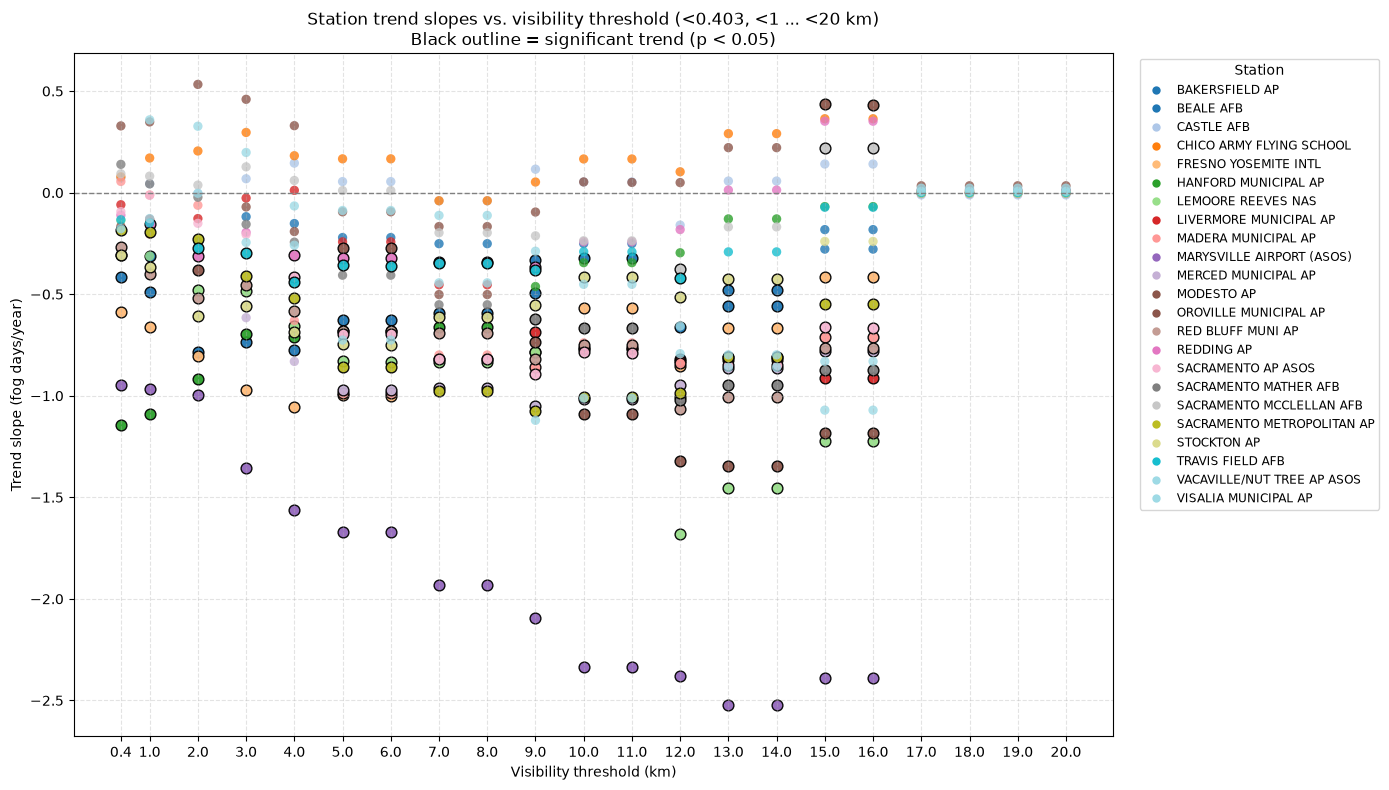

In [39]:
# Scatterplot of station trend slopes by visibility threshold:
# thresholds: <0.403 km, <1 km, <2 km, ... <20 km
# Uses existing trend_rows_1980 and computes <0.403 km trends to match that period (year >= 1980).

source_trend_rows = trend_rows_1980  # switch to trend_rows_2000 if you want post-2000 instead
trend_df = pd.DataFrame(source_trend_rows).copy()

# Keep integer thresholds from 1 to 20 km (inclusive) for plotting
trend_df = trend_df[trend_df["threshold_km"].between(1, 20)].copy()

# Build <0.403 km station trends (aligned to 1980+ window used above)
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

th_0403_df = base_df[base_df["HourlyVisibility"] < 0.403].copy()
annual_0403 = (
    th_0403_df
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

rows_0403 = []
for station, sdf in annual_0403.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 10:
        continue
    model = smf.ols("fog_days ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    rows_0403.append({
        "threshold_km": 0.403,
        "STATION": station,
        "n_obs": len(sdf),
        "min_year": int(sdf["year"].min()),
        "max_year": int(sdf["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": pval,
        "trend_significant": pval < 0.05,
    })

trend_0403 = pd.DataFrame(rows_0403)

# Combine
plot_df = pd.concat([trend_0403, trend_df], ignore_index=True)
plot_df = plot_df.sort_values(["STATION", "threshold_km"]).copy()

# Color map by station
stations = sorted(plot_df["STATION"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

for st in stations:
    sdf = plot_df[plot_df["STATION"] == st]
    nonsig = sdf[~sdf["trend_significant"]]
    sig = sdf[sdf["trend_significant"]]

    # Non-significant points: station color, no black outline
    ax.scatter(
        nonsig["threshold_km"], nonsig["slope"],
        s=45, color=station_color[st], alpha=0.8, edgecolors="none"
    )

    # Significant points: station color + black outline
    ax.scatter(
        sig["threshold_km"], sig["slope"],
        s=60, color=station_color[st], alpha=0.95,
        edgecolors="black", linewidths=1.0
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Visibility threshold (km)")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station trend slopes vs. visibility threshold (<0.403, <1 ... <20 km)\nBlack outline = significant trend (p < 0.05)")
ax.set_xticks([0.403] + list(range(1, 21)))
ax.grid(True, linestyle="--", alpha=0.35)

# Legend (station colors)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]
ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()

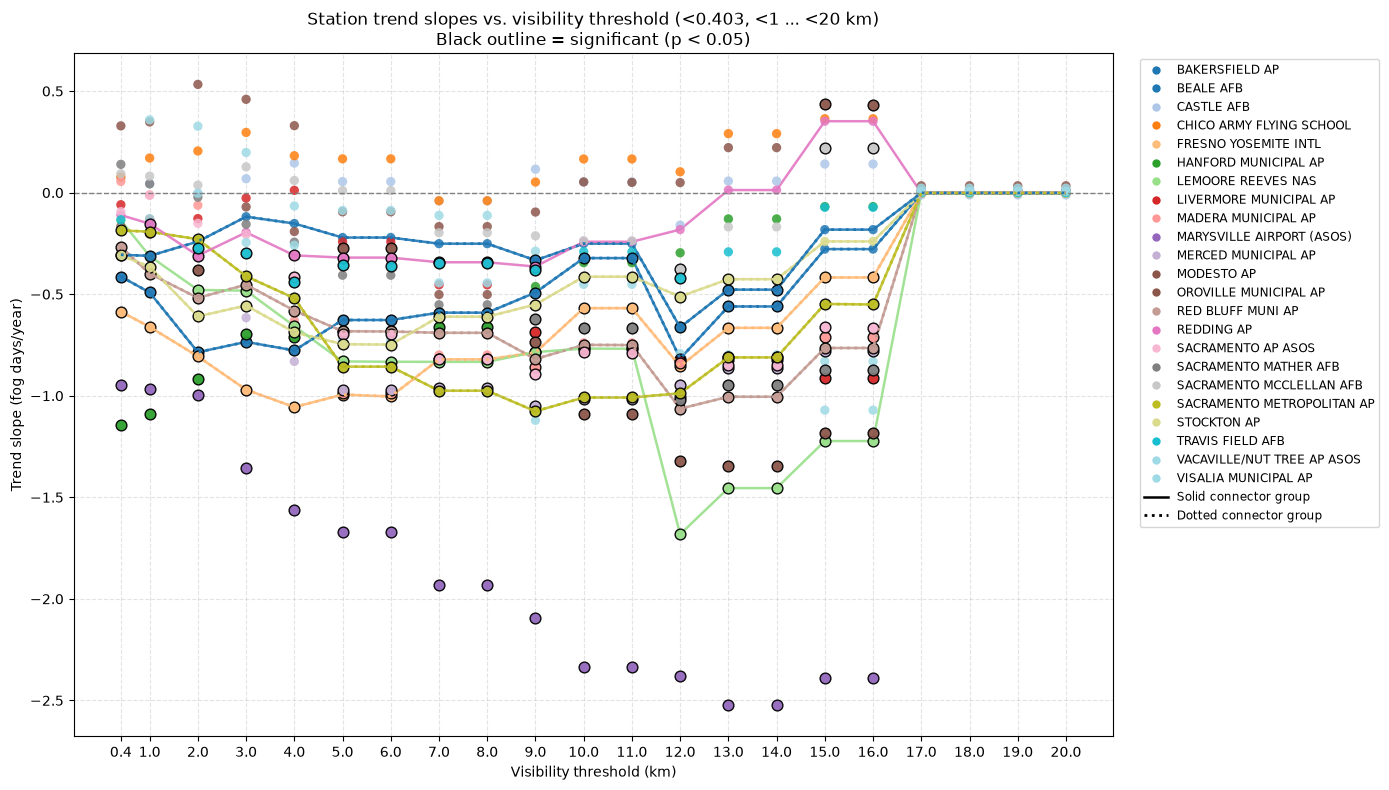

In [41]:
# Build slope-vs-threshold plot (1980+) with:
# - station-colored scatter points
# - black outline for significant trends
# - solid connector lines for one station set
# - dotted connector lines for another station set

# Base trends from existing list (1980+), keep thresholds 1..20
trend_df_1980 = pd.DataFrame(trend_rows_1980).copy()
trend_df_1980 = trend_df_1980[trend_df_1980["threshold_km"].between(1, 20)].copy()

# Compute <0.403 km trends for the same 1980+ window
if "df_1980" in globals():
    base_df_1980 = df_1980.copy()
else:
    base_df_1980 = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

th_0403_df = base_df_1980[base_df_1980["HourlyVisibility"] < 0.403].copy()
annual_0403 = (
    th_0403_df
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

rows_0403 = []
for station, sdf in annual_0403.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 10:
        continue
    model = smf.ols("fog_days ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    rows_0403.append({
        "threshold_km": 0.403,
        "STATION": station,
        "n_obs": len(sdf),
        "min_year": int(sdf["year"].min()),
        "max_year": int(sdf["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": pval,
        "trend_significant": pval < 0.05,
    })

trend_0403 = pd.DataFrame(rows_0403)

# Combine for plotting
plot_df = pd.concat([trend_0403, trend_df_1980], ignore_index=True)
plot_df = plot_df.sort_values(["STATION", "threshold_km"]).copy()

# Station colors
stations = sorted(plot_df["STATION"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Line-connection station groups
solid_stations = [
    "FRESNO YOSEMITE INTL", "BAKERSFIELD AP", "RED BLUFF MUNI AP", "STOCKTON AP",
    "BEALE AFB", "LEMOORE REEVES NAS", "SACRAMENTO METROPOLITAN AP", "REDDING AP"
]
dotted_stations = [
    "FRESNO YOSEMITE INTL", "BAKERSFIELD AP", "RED BLUFF MUNI AP",
    "STOCKTON AP", "BEALE AFB", "SACRAMENTO METROPOLITAN AP"
]

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter points by station (outlined if significant)
for st in stations:
    sdf = plot_df[plot_df["STATION"] == st]
    nonsig = sdf[~sdf["trend_significant"]]
    sig = sdf[sdf["trend_significant"]]

    ax.scatter(
        nonsig["threshold_km"], nonsig["slope"],
        s=45, color=station_color[st], alpha=0.85, edgecolors="none", zorder=2
    )
    ax.scatter(
        sig["threshold_km"], sig["slope"],
        s=60, color=station_color[st], alpha=0.95,
        edgecolors="black", linewidths=1.0, zorder=3
    )

# Solid connectors
for st in solid_stations:
    sdf = plot_df[plot_df["STATION"] == st].sort_values("threshold_km")
    if sdf.empty:
        continue
    ax.plot(
        sdf["threshold_km"], sdf["slope"],
        linestyle="-", linewidth=1.8, color=station_color.get(st, "gray"),
        alpha=0.9, zorder=1
    )

# Dotted connectors
for st in dotted_stations:
    sdf = plot_df[plot_df["STATION"] == st].sort_values("threshold_km")
    if sdf.empty:
        continue
    ax.plot(
        sdf["threshold_km"], sdf["slope"],
        linestyle=":", linewidth=2.0, color=station_color.get(st, "gray"),
        alpha=1.0, zorder=4
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Visibility threshold (km)")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title(
    "Station trend slopes vs. visibility threshold (<0.403, <1 ... <20 km)\n"
    "Black outline = significant (p < 0.05)"
)
ax.set_xticks([0.403] + list(range(1, 21)))
ax.grid(True, linestyle="--", alpha=0.35)

# Legend for stations (color)
station_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]
# Legend for line styles
style_handles = [
    plt.Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label="Solid connector group"),
    plt.Line2D([0], [0], color="black", linestyle=":", linewidth=2.0, label="Dotted connector group"),
]
ax.legend(handles=station_handles + style_handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()

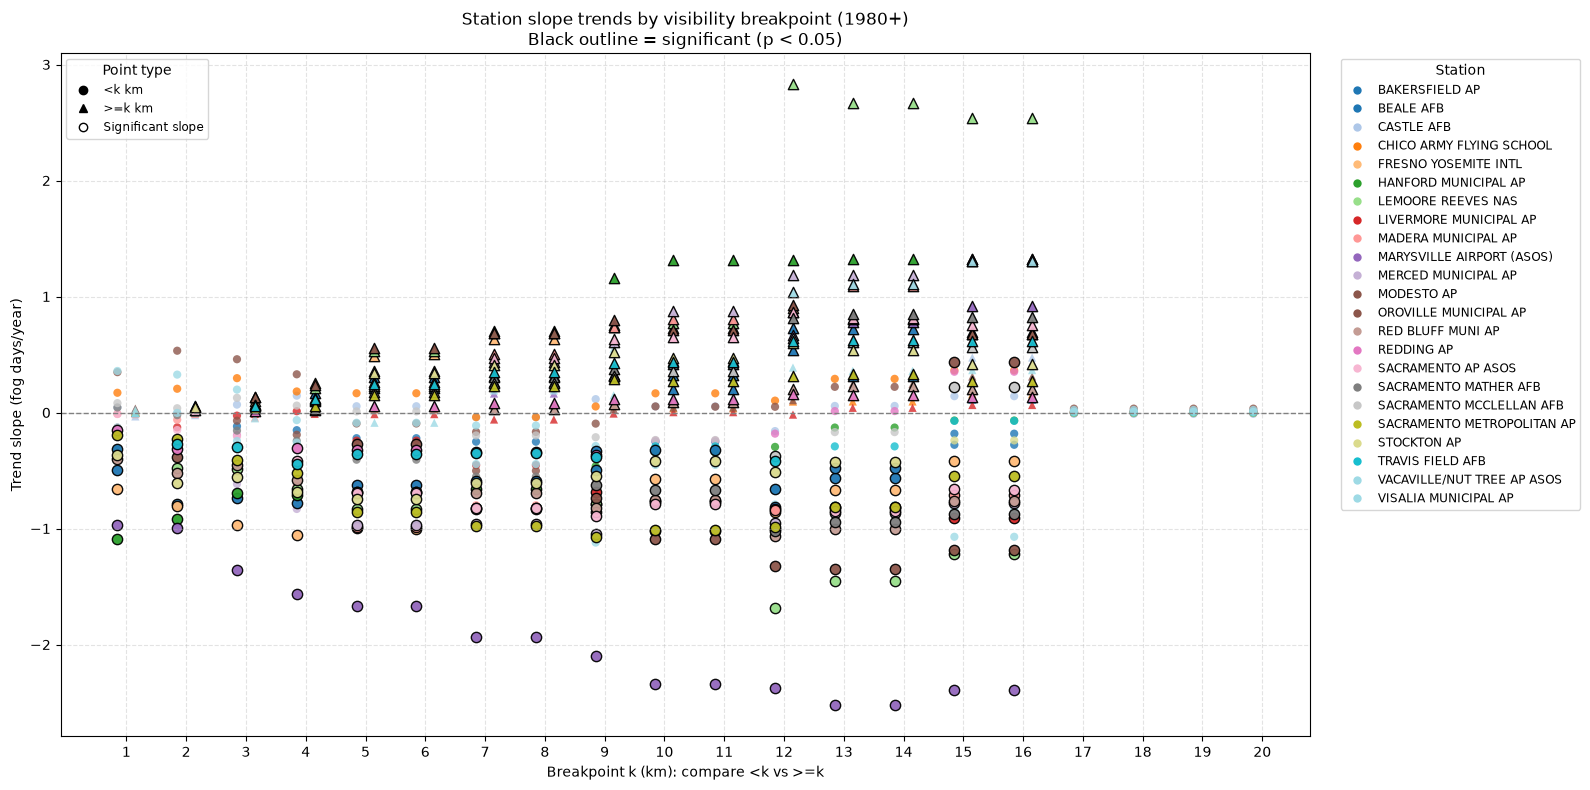

In [42]:
# Scatterplot of station trend slopes by breakpoint:
# (<k km) vs (>=k km), for k = 1..20, using 1980+ period.

breakpoints = list(range(1, 21))
p_cutoff = 0.05

# Base data window aligned with trend_rows_1980 logic
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

# Use existing <k trends from trend_rows_1980
lt_df = pd.DataFrame(trend_rows_1980).copy()
lt_df = lt_df[lt_df["threshold_km"].isin(breakpoints)].copy()
lt_df["group"] = "lt"  # <k

# Compute >=k trends
ge_rows = []
for k in breakpoints:
    ge_k = base_df[base_df["HourlyVisibility"] >= k].copy()
    annual_ge = (
        ge_k
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual_ge.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("fog_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        ge_rows.append({
            "threshold_km": k,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
            "group": "ge",  # >=k
        })

ge_df = pd.DataFrame(ge_rows)

# Combine
plot_df = pd.concat([lt_df, ge_df], ignore_index=True)

# Station colors
stations = sorted(plot_df["STATION"].dropna().unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
x_offset = {"lt": -0.15, "ge": 0.15}
marker_map = {"lt": "o", "ge": "^"}
label_map = {"lt": "<k km", "ge": ">=k km"}

for grp in ["lt", "ge"]:
    gdf = plot_df[plot_df["group"] == grp].copy()
    gdf["xpos"] = gdf["threshold_km"] + x_offset[grp]

    # Non-significant
    nonsig = gdf[~gdf["trend_significant"]]
    for st, sdf in nonsig.groupby("STATION"):
        ax.scatter(
            sdf["xpos"], sdf["slope"],
            s=35, marker=marker_map[grp],
            color=station_color[st], alpha=0.8, edgecolors="none"
        )

    # Significant (black outline)
    sig = gdf[gdf["trend_significant"]]
    for st, sdf in sig.groupby("STATION"):
        ax.scatter(
            sdf["xpos"], sdf["slope"],
            s=55, marker=marker_map[grp],
            color=station_color[st], alpha=0.95,
            edgecolors="black", linewidths=1.0
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(breakpoints)
ax.set_xlabel("Breakpoint k (km): compare <k vs >=k")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station slope trends by visibility breakpoint (1980+)\nBlack outline = significant (p < 0.05)")
ax.grid(True, linestyle="--", alpha=0.35)

# Legends
group_handles = [
    plt.Line2D([0], [0], marker=marker_map["lt"], linestyle="", color="black", label=label_map["lt"]),
    plt.Line2D([0], [0], marker=marker_map["ge"], linestyle="", color="black", label=label_map["ge"]),
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black",
               label="Significant slope")
]
station_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]

legend1 = ax.legend(handles=group_handles, loc="upper left", fontsize="small", title="Point type")
ax.add_artist(legend1)
ax.legend(handles=station_handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small", title="Station")

plt.tight_layout()
plt.show()

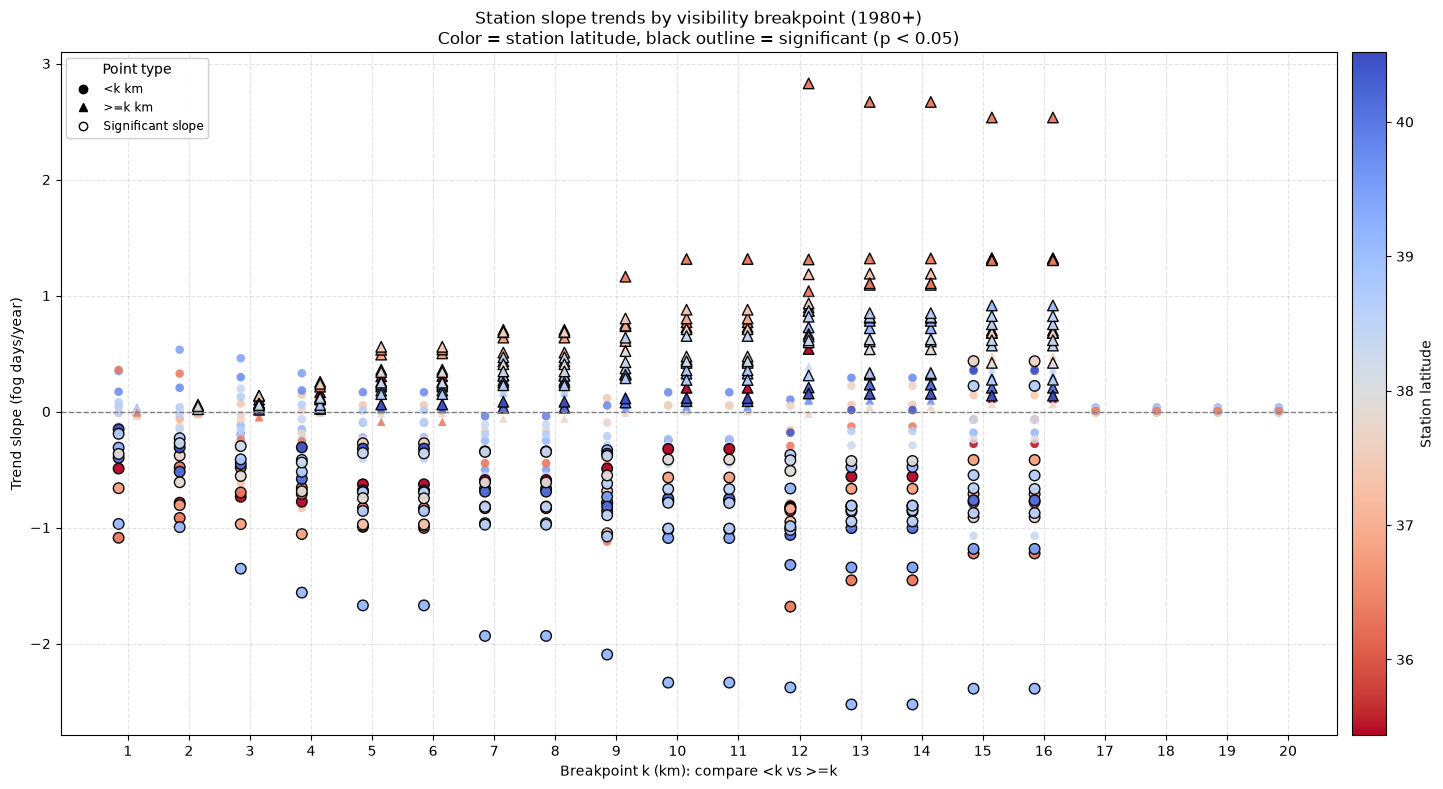

In [46]:
# Same breakpoint plot (<k vs >=k, 1980+) but color stations by latitude

breakpoints = list(range(1, 21))
p_cutoff = 0.05

# Base 1980+ data
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["year"] >= 1980].copy()

# Station latitude lookup
station_lat = (
    CV_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

# <k trends from existing results
lt_df = pd.DataFrame(trend_rows_1980).copy()
lt_df = lt_df[lt_df["threshold_km"].isin(breakpoints)].copy()
lt_df["group"] = "lt"

# >=k trends
ge_rows = []
for k in breakpoints:
    ge_k = base_df[base_df["HourlyVisibility"] >= k].copy()
    annual_ge = (
        ge_k
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual_ge.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("fog_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        ge_rows.append({
            "threshold_km": k,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
            "group": "ge",
        })

ge_df = pd.DataFrame(ge_rows)

# Combine and attach latitude
plot_df = pd.concat([lt_df, ge_df], ignore_index=True)
plot_df = plot_df.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"]).copy()

# Colormap by latitude
lat_min, lat_max = plot_df["latitude"].min(), plot_df["latitude"].max()
norm = plt.Normalize(lat_min, lat_max)
cmap = plt.cm.coolwarm_r # cool is blue (higher lat), warm is red (lower lat)

# Plot style
x_offset = {"lt": -0.15, "ge": 0.15}
marker_map = {"lt": "o", "ge": "^"}

fig, ax = plt.subplots(figsize=(16, 8))

for grp in ["lt", "ge"]:
    gdf = plot_df[plot_df["group"] == grp].copy()
    gdf["xpos"] = gdf["threshold_km"] + x_offset[grp]
    colors = cmap(norm(gdf["latitude"]))

    nonsig = gdf[~gdf["trend_significant"]]
    ax.scatter(
        nonsig["xpos"], nonsig["slope"],
        c=cmap(norm(nonsig["latitude"])),
        s=38, marker=marker_map[grp], alpha=0.85, edgecolors="none"
    )

    sig = gdf[gdf["trend_significant"]]
    ax.scatter(
        sig["xpos"], sig["slope"],
        c=cmap(norm(sig["latitude"])),
        s=58, marker=marker_map[grp], alpha=0.95,
        edgecolors="black", linewidths=1.0
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(breakpoints)
ax.set_xlabel("Breakpoint k (km): compare <k vs >=k")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station slope trends by visibility breakpoint (1980+)\nColor = station latitude, black outline = significant (p < 0.05)")
ax.grid(True, linestyle="--", alpha=0.35)

# Legends
group_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color="black", label="<k km"),
    plt.Line2D([0], [0], marker="^", linestyle="", color="black", label=">=k km"),
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black", label="Significant slope")
]
legend1 = ax.legend(handles=group_handles, loc="upper left", fontsize="small", title="Point type")
ax.add_artist(legend1)

smappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
smappable.set_array([])
cbar = plt.colorbar(smappable, ax=ax, pad=0.01)
cbar.set_label("Station latitude")

plt.tight_layout()
plt.show()

In [43]:
visibility = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
vis_gt_17_rows = CV_rows.loc[visibility > 17.0].copy()

print("Rows with HourlyVisibility > 17 km:", len(vis_gt_17_rows))
vis_gt_17_rows.head()

Rows with HourlyVisibility > 17 km: 0


,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION


c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Accoun

Significant threshold-based fog-day trends (p < 0.05):
 threshold_km                    STATION  n_obs     slope      p_value  r_squared
            1       FRESNO YOSEMITE INTL     70 -0.275792 3.267880e-07   0.320457
            1          RED BLUFF MUNI AP     64 -0.155250 2.431079e-04   0.196595
            1                STOCKTON AP     60 -0.151621 7.070788e-04   0.180820
            1         LEMOORE REEVES NAS     38 -0.325020 8.886037e-04   0.267302
            1  MARYSVILLE AIRPORT (ASOS)     16 -0.968735 1.716475e-03   0.516195
            1             BAKERSFIELD AP     82 -0.106475 5.121412e-03   0.093858
            1                  BEALE AFB     32 -0.187125 6.247903e-03   0.223799
            1           TRAVIS FIELD AFB     59 -0.132717 1.169815e-02   0.106387
            1       HANFORD MUNICIPAL AP     18 -1.088080 1.226091e-02   0.332387
            1         SACRAMENTO AP ASOS     75 -0.104224 1.682430e-02   0.075791
            1 SACRAMENTO METROPOLITAN AP   

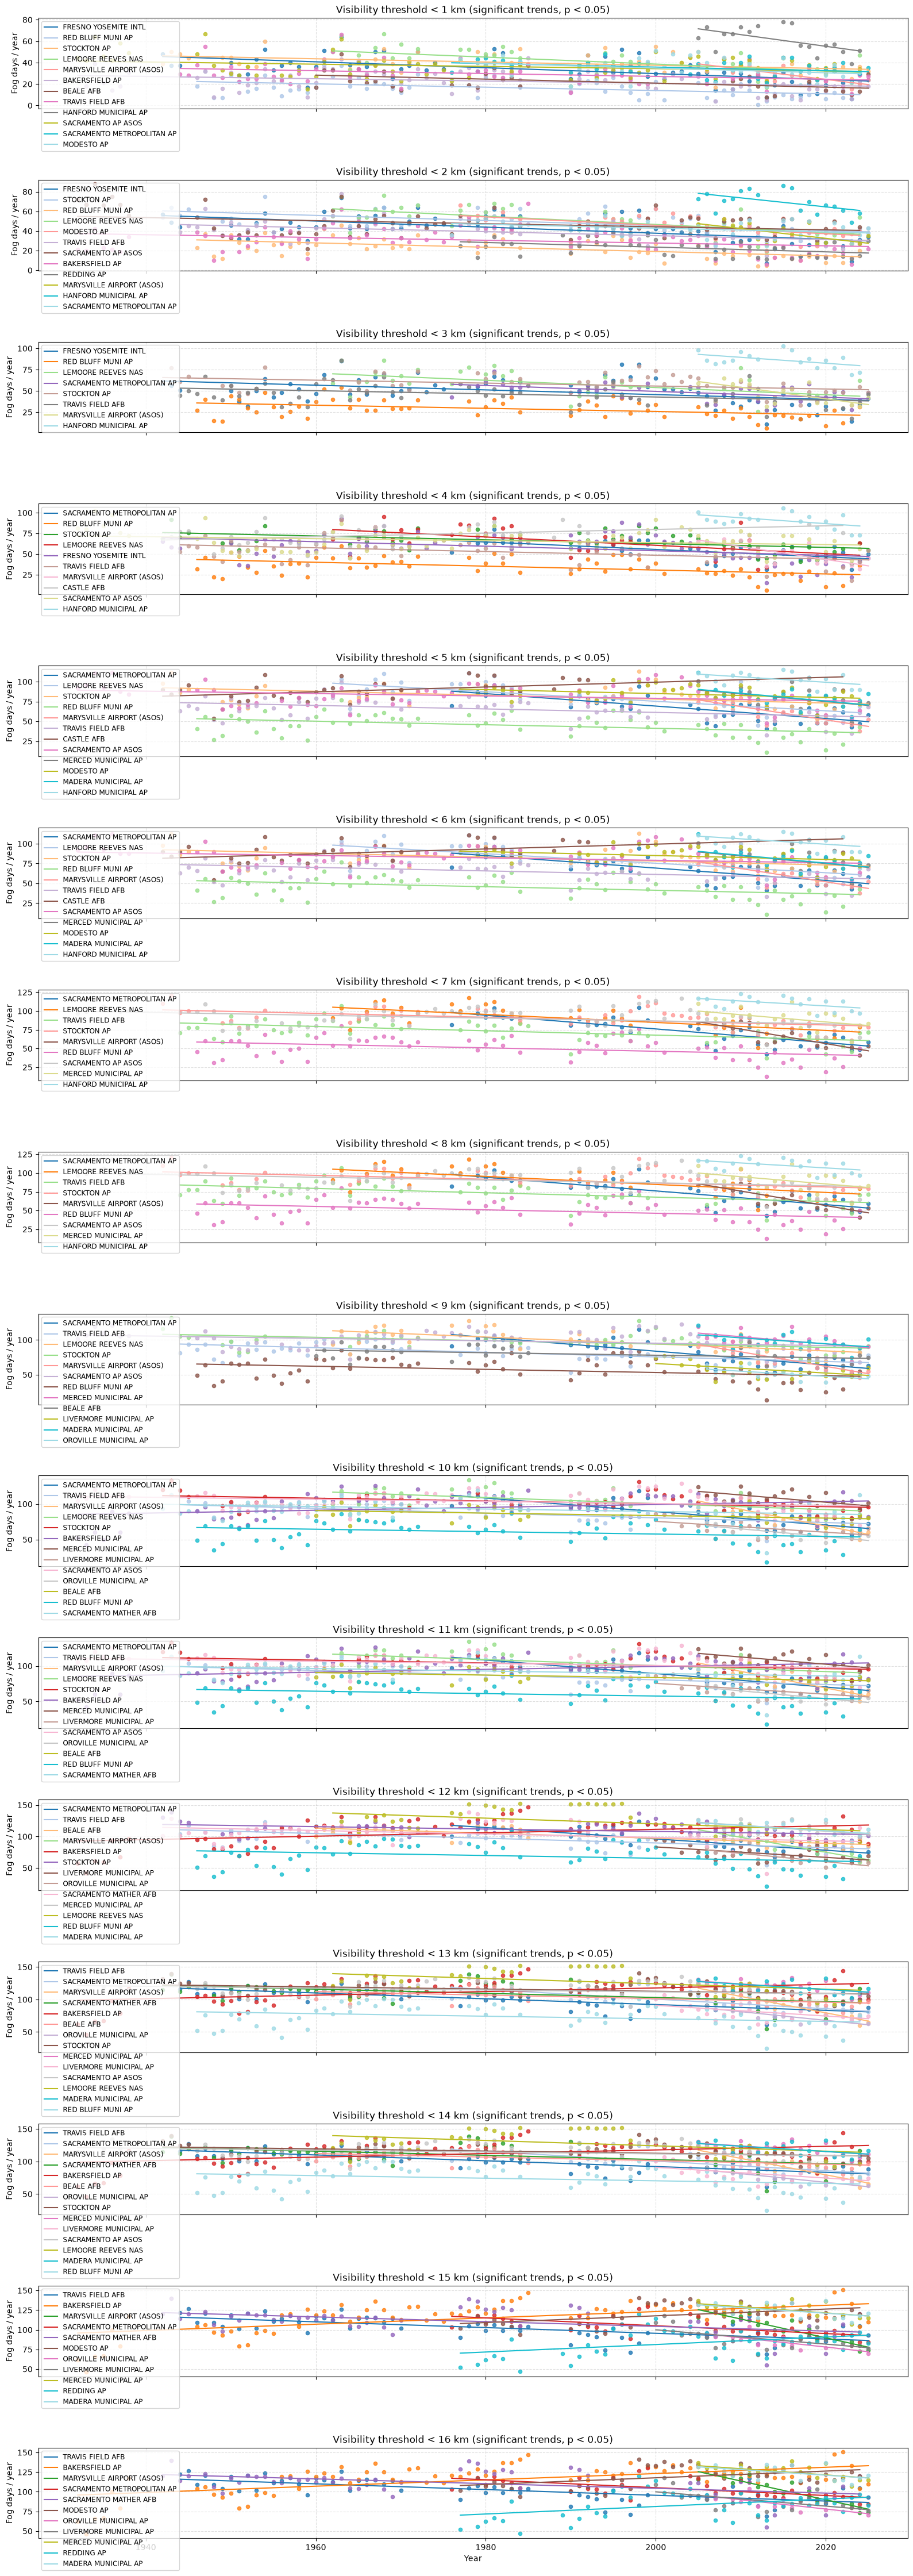

In [21]:
# Evaluate fog-day trends for increasing visibility thresholds (1 to 25 km)
# using the already-filtered CV_fog_rows_no_outliers dataframe.

p_cutoff = 0.05
thresholds = list(range(1, 26))

annual_by_threshold = {}
trend_rows = []

for threshold in thresholds:
    # Keep rows with visibility below the current threshold
    threshold_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < threshold].copy()

    # Count unique fog days per station-year (avoid double-counting same day)
    annual = (
        threshold_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )
    annual_by_threshold[threshold] = annual


    # Fit a simple linear trend for each station
    for station, station_df in annual.groupby("STATION", sort=False):
        station_df = station_df.sort_values("year")
        if len(station_df) < 3:
            continue

        model = smf.ols("fog_days ~ year", data=station_df).fit()
        p_value = float(model.pvalues["year"])

        if np.isnan(p_value):
            continue

        trend_rows.append({
            "threshold_km": threshold,
            "STATION": station,
            "n_obs": len(station_df),
            "min_year": int(station_df["year"].min()),
            "max_year": int(station_df["year"].max()),
            "slope": float(model.params["year"]),
            "intercept": float(model.params["Intercept"]),
            "r_squared": float(model.rsquared),
            "p_value": p_value,
            "trend_significant": p_value < p_cutoff,
        })

threshold_trends = pd.DataFrame(trend_rows).sort_values(["threshold_km", "p_value"])
significant_threshold_trends = threshold_trends[threshold_trends["trend_significant"]].copy()

print("Significant threshold-based fog-day trends (p < 0.05):")
print(
    significant_threshold_trends[
        ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
    ].sort_values(["threshold_km", "p_value"]).to_string(index=False)
)

# Plot the significant trendlines by threshold
if not significant_threshold_trends.empty:
    thresholds_with_significant = sorted(significant_threshold_trends["threshold_km"].unique())

    fig, axes = plt.subplots(
        len(thresholds_with_significant),
        1,
        figsize=(16, 2.8 * len(thresholds_with_significant)),
        sharex=True
    )

    if len(thresholds_with_significant) == 1:
        axes = [axes]

    for ax, threshold in zip(axes, thresholds_with_significant):
        th_df = significant_threshold_trends[significant_threshold_trends["threshold_km"] == threshold].copy()
        ax.set_title(f"Visibility threshold < {threshold} km (significant trends, p < 0.05)")

        stations_for_threshold = th_df["STATION"].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
        color_map = dict(zip(stations_for_threshold, colors))

        for station in stations_for_threshold:
            row = th_df[th_df["STATION"] == station].iloc[0]
            station_df = annual_by_threshold[threshold][
                annual_by_threshold[threshold]["STATION"] == station
            ].sort_values("year")

            if station_df.empty:
                continue

            color = color_map[station]

            # Observed annual fog days
            ax.scatter(
                station_df["year"],
                station_df["fog_days"],
                s=20,
                color=color,
                alpha=0.8
            )

            # Fitted trend line
            x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
            y_hat = row["intercept"] + row["slope"] * x
            ax.plot(x, y_hat, color=color, linewidth=1.5, label=station)

        ax.set_ylabel("Fog days / year")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    axes[-1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()
else:
    print("No significant trends were found at the selected p-value threshold.")

Visibility threshold: < 17 km
Annual total fog days (all stations): 91
                            OLS Regression Results                            
Dep. Variable:               fog_days   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     60.78
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.14e-11
Time:                        11:13:42   Log-Likelihood:                -740.66
No. Observations:                  91   AIC:                             1485.
Df Residuals:                      89   BIC:                             1490.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

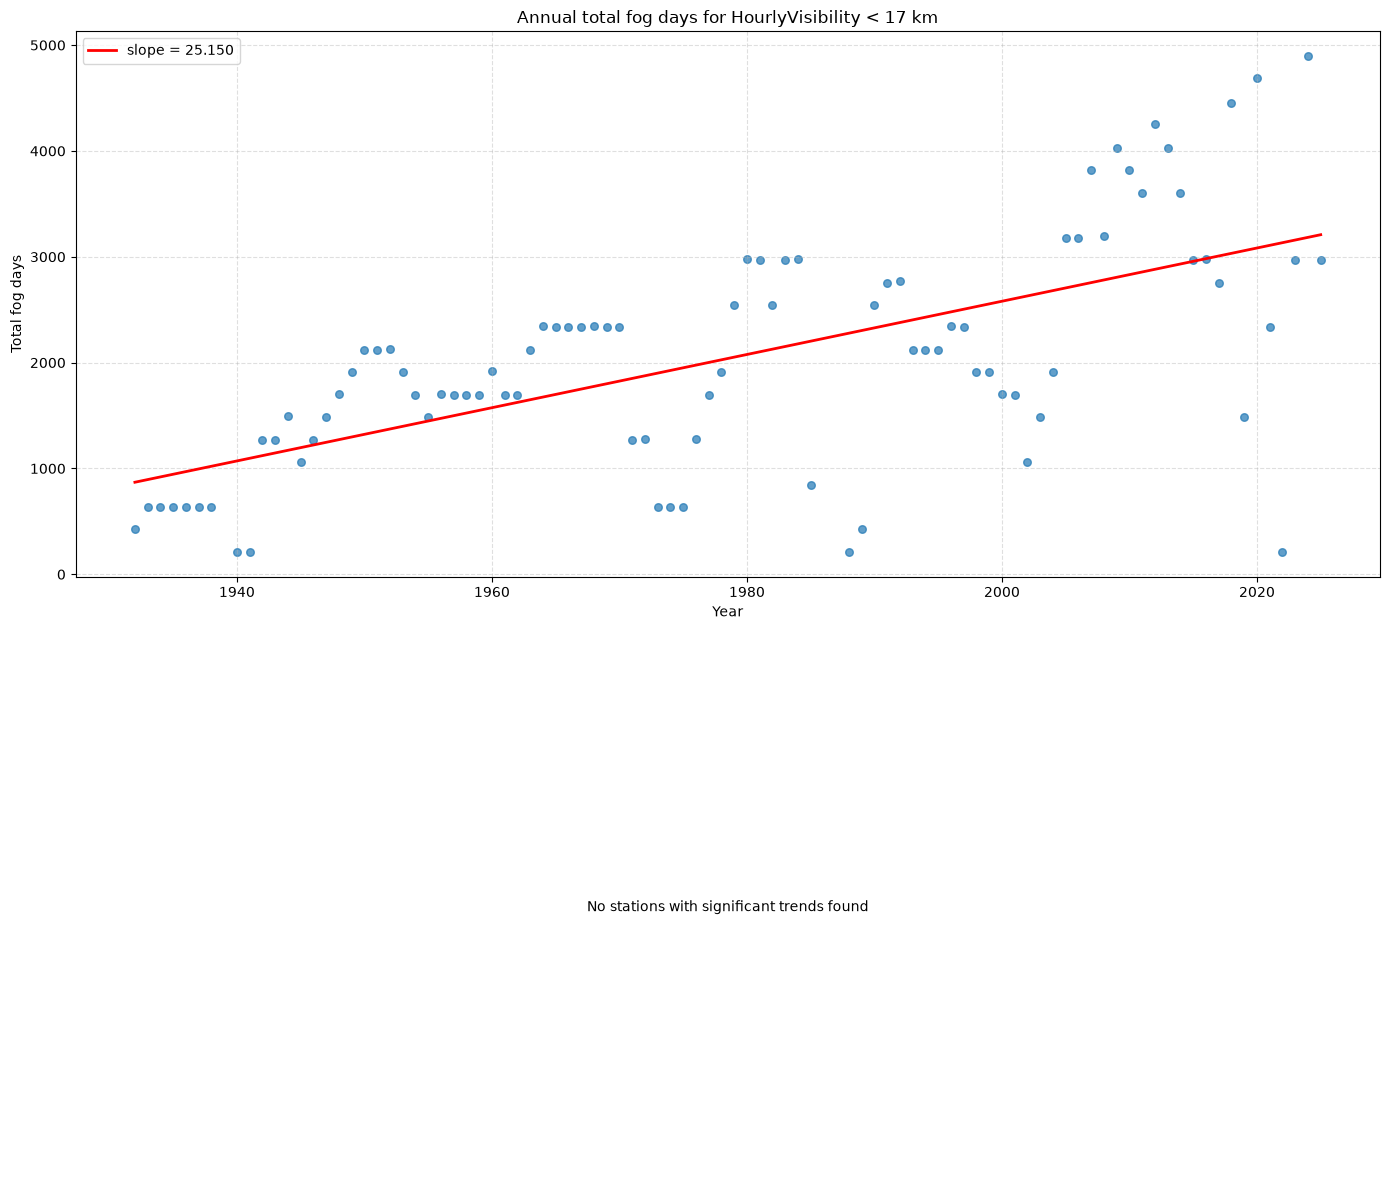

In [54]:
threshold = 17

threshold_df = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < threshold].copy()

annual_vis_lt_17 = (
    threshold_df
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

annual_total_vis_lt_17 = (
    annual_vis_lt_17
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_total = smf.ols("fog_days ~ year", data=annual_total_vis_lt_17).fit()

print(f"Visibility threshold: < {threshold} km")
print("Annual total fog days (all stations):", annual_total_vis_lt_17.shape[0])
print(model_total.summary())

trend_rows_17 = []
for station, station_df in annual_vis_lt_17.groupby("STATION", sort=False):
    station_df = station_df.sort_values("year")
    if len(station_df) < 10:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_rows_17.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": int(station_df["year"].min()),
        "max_year": int(station_df["year"].max()),
        "slope": float(model.params["year"]),
        "intercept": float(model.params["Intercept"]),
        "r_squared": float(model.rsquared),
        "p_value": float(model.pvalues["year"]),
        "trend_significant": float(model.pvalues["year"]) < 0.05,
    })

trend_vis_lt_17 = pd.DataFrame(trend_rows_17).sort_values(["trend_significant", "p_value"])
significant_vis_lt_17 = trend_vis_lt_17[trend_vis_lt_17["trend_significant"]].copy()

print("\nStation-level trends for visibility < 17 km")
print(f"Stations with significant trends: {len(significant_vis_lt_17)}")
print(significant_vis_lt_17[["STATION", "n_obs", "min_year", "max_year", "slope", "p_value", "r_squared"]].head(20).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

axes[0].scatter(annual_total_vis_lt_17["year"], annual_total_vis_lt_17["fog_days"], s=30, alpha=0.7)
axes[0].plot(
    annual_total_vis_lt_17["year"],
    model_total.predict(annual_total_vis_lt_17),
    color="red",
    linewidth=2,
    label=f"slope = {model_total.params['year']:.3f}"
)
axes[0].set_title(f"Annual total fog days for HourlyVisibility < {threshold} km")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total fog days")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

selected_stations = significant_vis_lt_17.sort_values("p_value").head(6)["STATION"].tolist()
if selected_stations:
    color_map = dict(zip(selected_stations, plt.cm.tab10(np.arange(len(selected_stations)))))
    for station in selected_stations:
        station_df = annual_vis_lt_17[annual_vis_lt_17["STATION"] == station].sort_values("year")
        model = smf.ols("fog_days ~ year", data=station_df).fit()
        axes[1].scatter(station_df["year"], station_df["fog_days"], s=20, alpha=0.8, color=color_map[station], label=station)
        axes[1].plot(
            station_df["year"],
            model.predict(station_df),
            color=color_map[station],
            linewidth=1.5
        )

    axes[1].set_title("Selected stations with significant trends (visibility < 17 km)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Fog days")
    axes[1].grid(True, linestyle="--", alpha=0.4)
    axes[1].legend(fontsize="small", loc="best")
else:
    axes[1].text(0.5, 0.5, "No stations with significant trends found", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Accoun

Significant threshold-based fog-day trends (long-record stations, p < 0.05):
 threshold_km               STATION  n_obs     slope      p_value  r_squared
            1  FRESNO YOSEMITE INTL     67 -0.254330 3.276537e-06   0.285045
            1     RED BLUFF MUNI AP     63 -0.152168 3.419306e-04   0.190997
            1 SACRAMENTO MATHER AFB     52 -0.172718 1.217712e-03   0.190494
            1    LEMOORE REEVES NAS     37 -0.321967 2.809506e-03   0.227909
            1           STOCKTON AP     57 -0.121253 1.008710e-02   0.114357
            1    SACRAMENTO AP ASOS     74 -0.110847 1.324700e-02   0.082231
            1        BAKERSFIELD AP     80 -0.083377 2.753435e-02   0.060744
            1             BEALE AFB     31 -0.157387 3.545126e-02   0.143709
            2           STOCKTON AP     57 -0.287237 9.906452e-08   0.405913
            2  FRESNO YOSEMITE INTL     67 -0.300166 2.198877e-06   0.293477
            2     RED BLUFF MUNI AP     63 -0.217710 1.378919e-05   0.268229

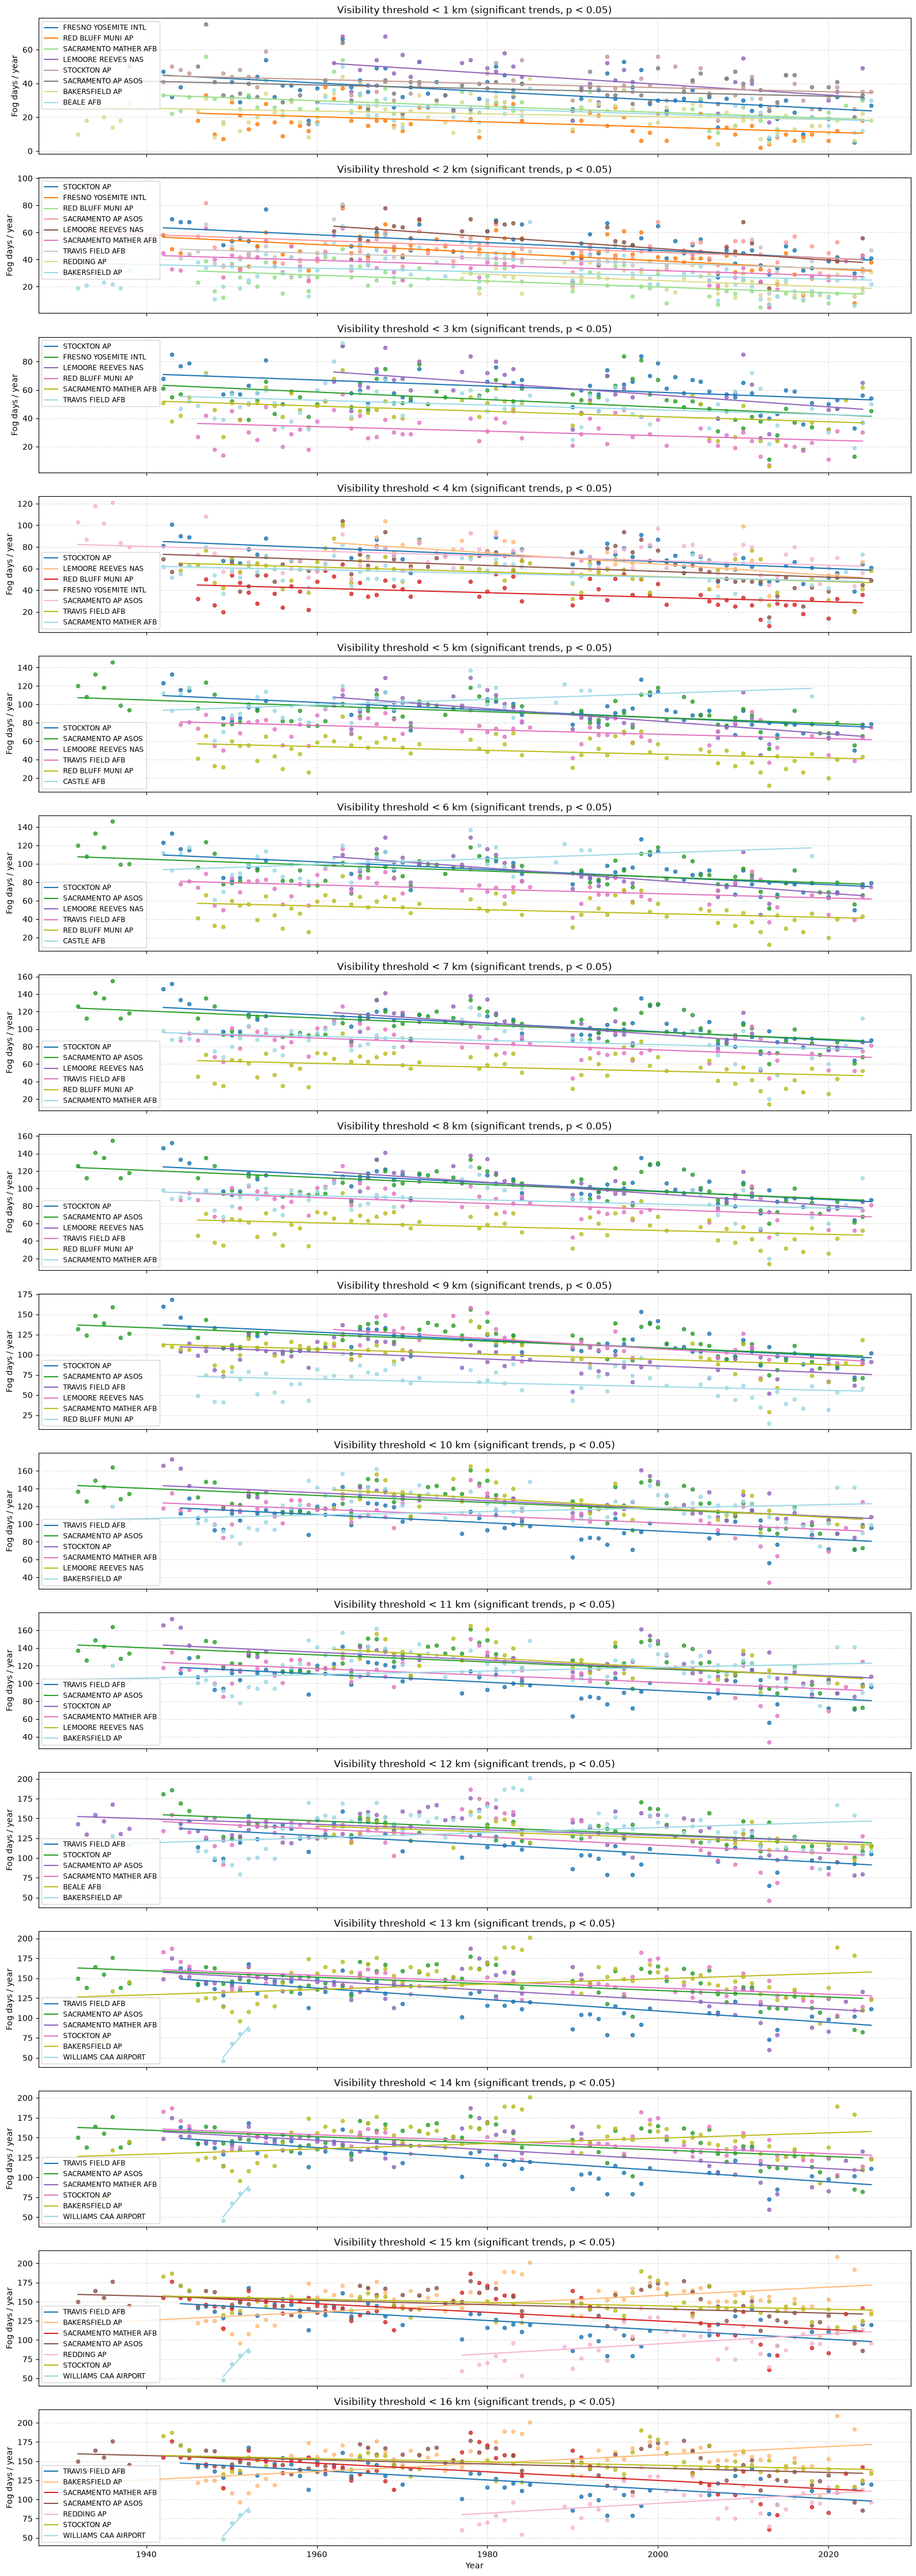

In [51]:
# Restrict threshold-based trend analysis to stations with long records
# long_stations = list(stations_with_30_years)  # from earlier cells
long_stations = list(filtered_plot_stations)  # from earlier cells
p_cutoff = 0.05
thresholds = list(range(1, 26))

annual_by_threshold_long = {}
trend_rows_long = []

for threshold in thresholds:
    # rows below threshold and only for long-record stations
    threshold_df = CV_fog_rows_no_outliers[
        (CV_fog_rows_no_outliers["HourlyVisibility"] < threshold) &
        (CV_fog_rows_no_outliers["STATION"].isin(long_stations))
    ].copy()

    annual = (
        threshold_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )
    annual_by_threshold_long[threshold] = annual

    for station, station_df in annual.groupby("STATION", sort=False):
        station_df = station_df.sort_values("year")
        if len(station_df) < 3:
            continue
        model = smf.ols("fog_days ~ year", data=station_df).fit()
        p_value = float(model.pvalues.get("year", np.nan))
        if np.isnan(p_value):
            continue
        trend_rows_long.append({
            "threshold_km": threshold,
            "STATION": station,
            "n_obs": len(station_df),
            "min_year": int(station_df["year"].min()),
            "max_year": int(station_df["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": p_value,
            "trend_significant": p_value < p_cutoff,
        })

threshold_trends_long = pd.DataFrame(trend_rows_long).sort_values(["threshold_km", "p_value"])
significant_threshold_trends_long = threshold_trends_long[threshold_trends_long["trend_significant"]].copy()

print("Significant threshold-based fog-day trends (long-record stations, p < 0.05):")
if significant_threshold_trends_long.empty:
    print("No significant trends found for long-record stations.")
else:
    display_cols = ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
    print(significant_threshold_trends_long[display_cols].sort_values(["threshold_km", "p_value"]).to_string(index=False))

    # Plot significant trendlines by threshold
    thresholds_with_significant = sorted(significant_threshold_trends_long["threshold_km"].unique())

    fig, axes = plt.subplots(
        len(thresholds_with_significant),
        1,
        figsize=(16, 2.8 * len(thresholds_with_significant)),
        sharex=True
    )

    if len(thresholds_with_significant) == 1:
        axes = [axes]

    for ax, threshold in zip(axes, thresholds_with_significant):
        th_df = significant_threshold_trends_long[significant_threshold_trends_long["threshold_km"] == threshold].copy()
        ax.set_title(f"Visibility threshold < {threshold} km (significant trends, p < 0.05)")

        stations_for_threshold = th_df["STATION"].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
        color_map = dict(zip(stations_for_threshold, colors))

        for station in stations_for_threshold:
            row = th_df[th_df["STATION"] == station].iloc[0]
            station_df = annual_by_threshold_long[threshold][annual_by_threshold_long[threshold]["STATION"] == station].sort_values("year")
            if station_df.empty:
                continue
            color = color_map[station]
            ax.scatter(station_df["year"], station_df["fog_days"], s=20, color=color, alpha=0.8)
            x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
            y_hat = row["intercept"] + row["slope"] * x
            ax.plot(x, y_hat, color=color, linewidth=1.5, label=station)

        ax.set_ylabel("Fog days / year")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    axes[-1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()

In [17]:
# Count hourly observations per station-year with HourlyVisibility > 16 km
vis = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
mask = vis > 16.0

counts_over_16 = (
    CV_rows.loc[mask, ["STATION", "year"]]
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "count_over_16"})
    .sort_values(["STATION", "year"])
)

print(counts_over_16.head())

          STATION  year  count_over_16
0  BAKERSFIELD AP  1928              1
1  BAKERSFIELD AP  1929           1242
2  BAKERSFIELD AP  1930              5
3  BAKERSFIELD AP  1931           4296
4  BAKERSFIELD AP  1932           7639


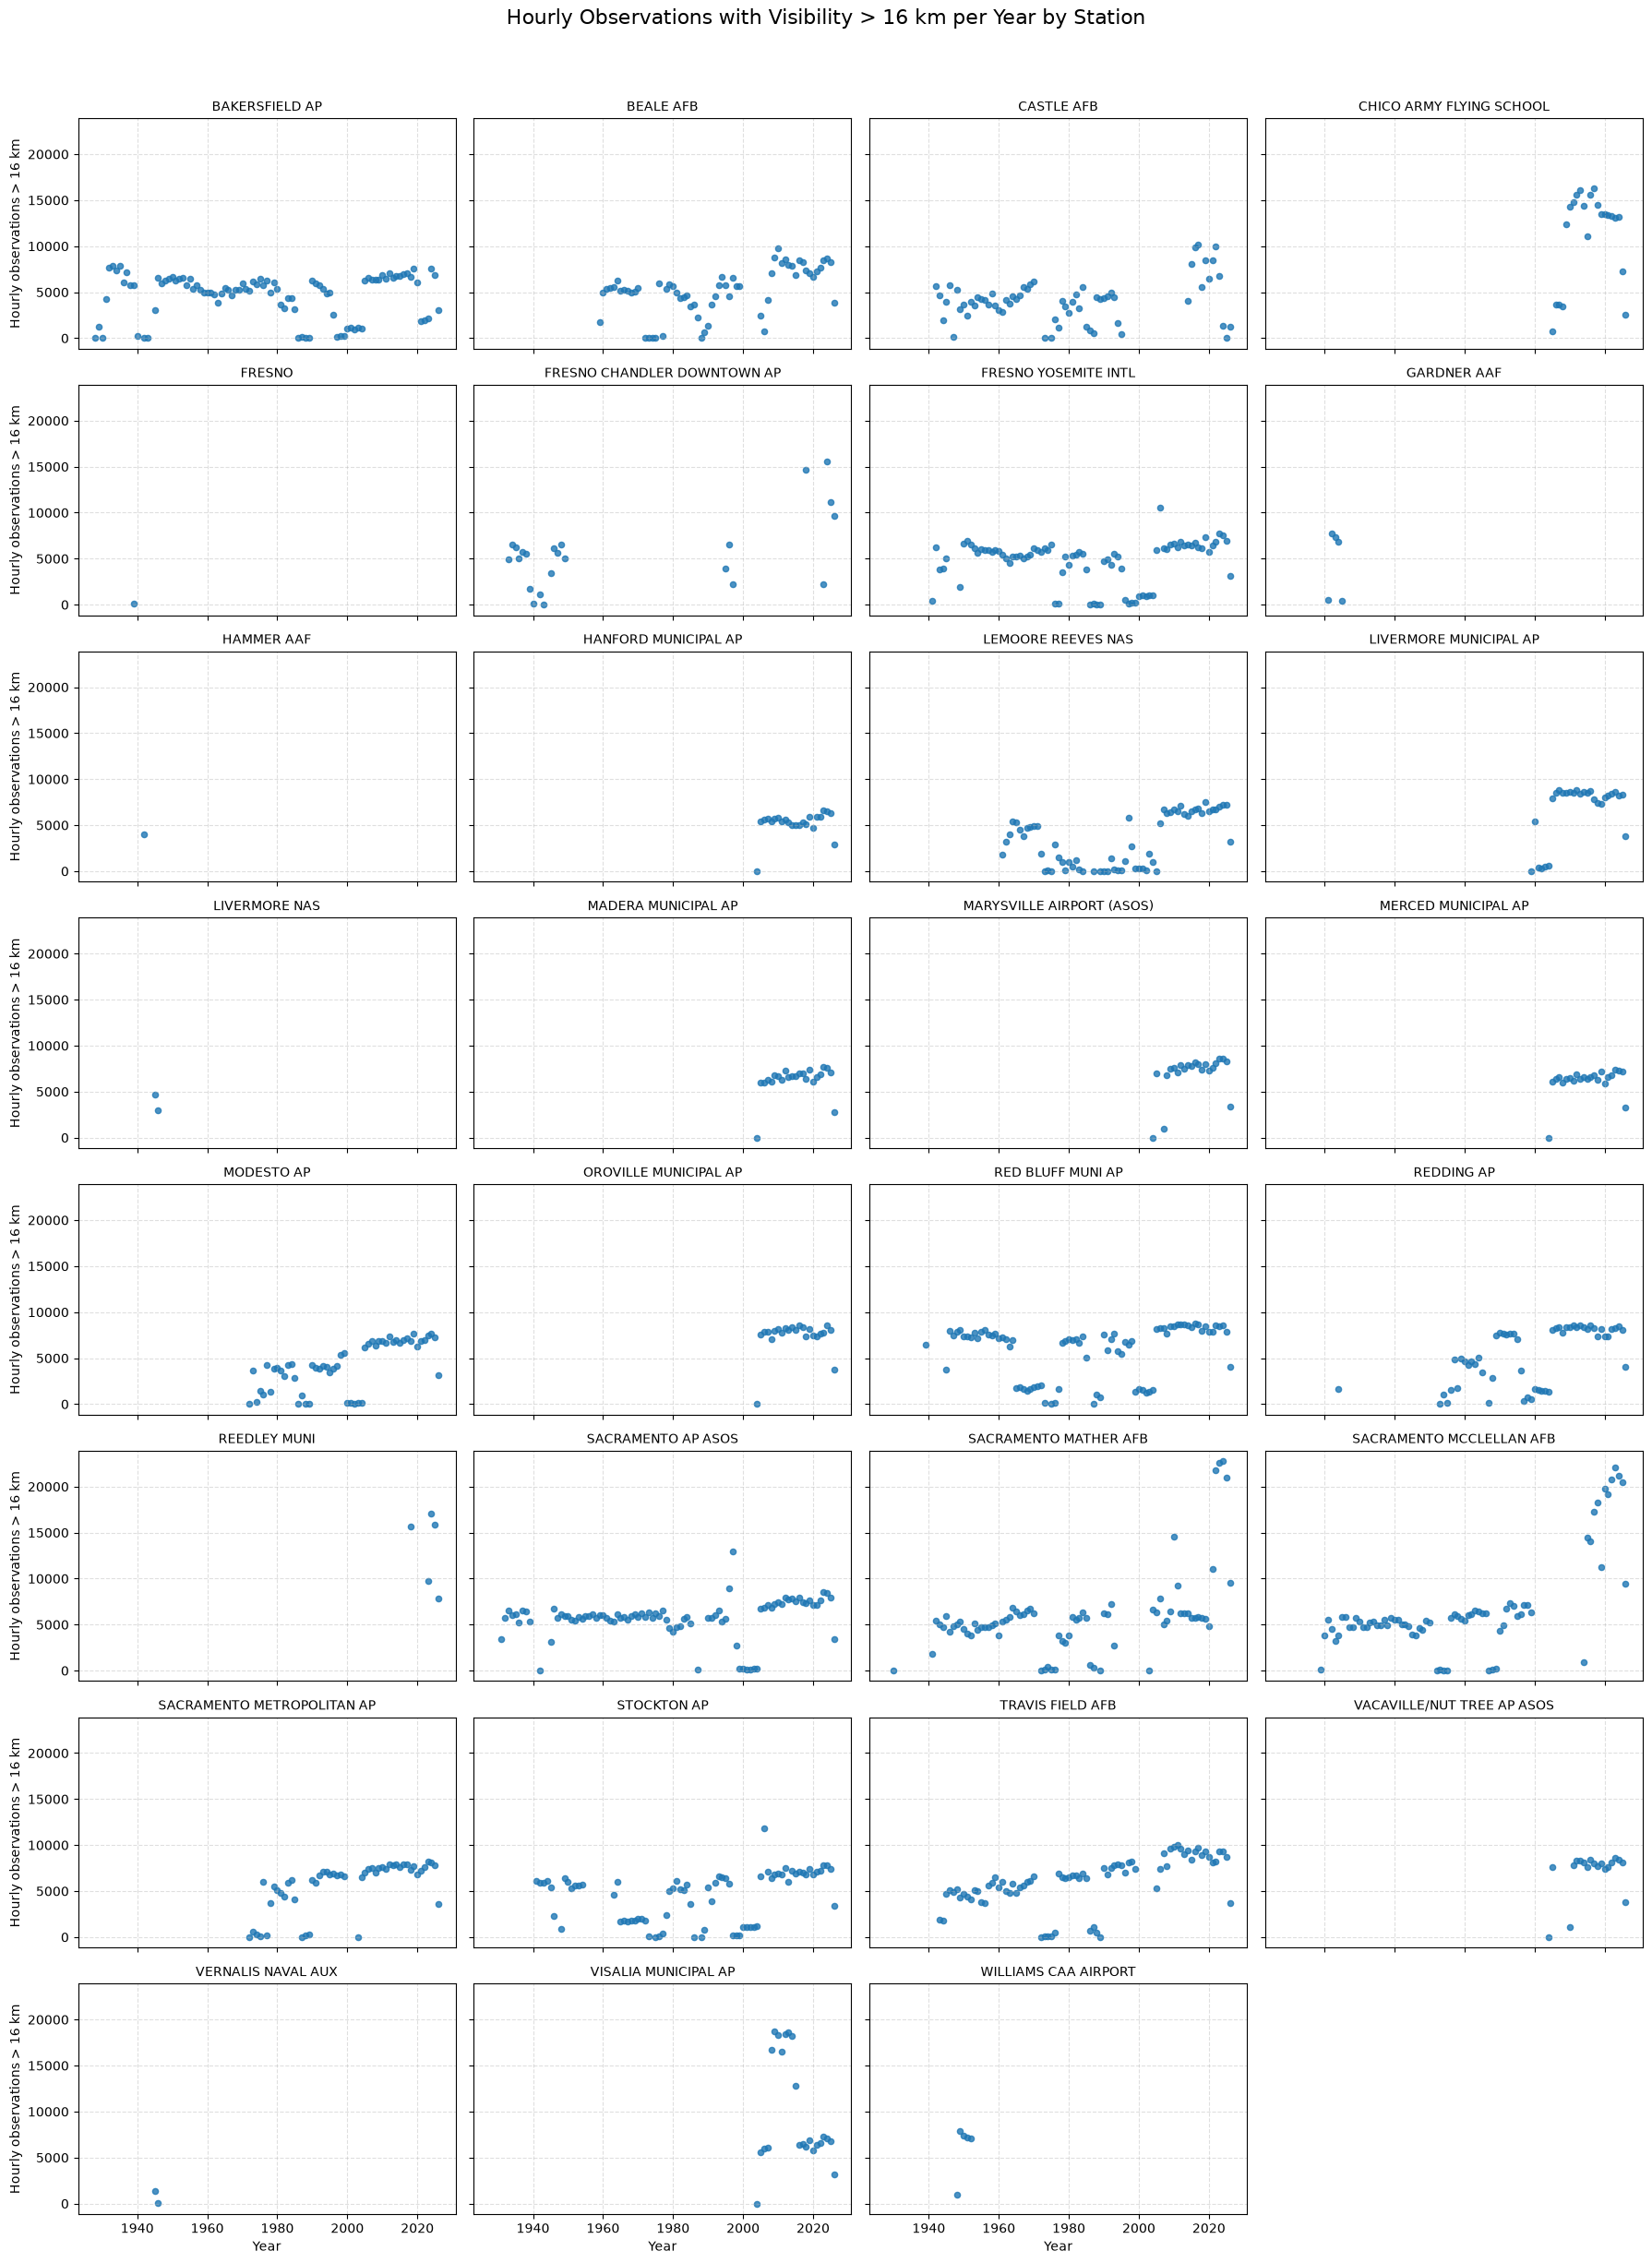

In [18]:
# Plot counters over 16 per station per year
stations = counts_over_16['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = counts_over_16[counts_over_16['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['count_over_16'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Hourly observations > 16 km')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Hourly Observations with Visibility > 16 km per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Count hourly observations per station-year with HourlyVisibility > 20 km
# vis = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
mask2 = vis > 20.0

counts_over_20 = (
    CV_rows.loc[mask2, ["STATION", "year"]]
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "count_over_20"})
    .sort_values(["STATION", "year"])
)

print(counts_over_20.head())

          STATION  year  count_over_20
0  BAKERSFIELD AP  1928              1
1  BAKERSFIELD AP  1929           1242
2  BAKERSFIELD AP  1930              5
3  BAKERSFIELD AP  1931           4288
4  BAKERSFIELD AP  1932           7559


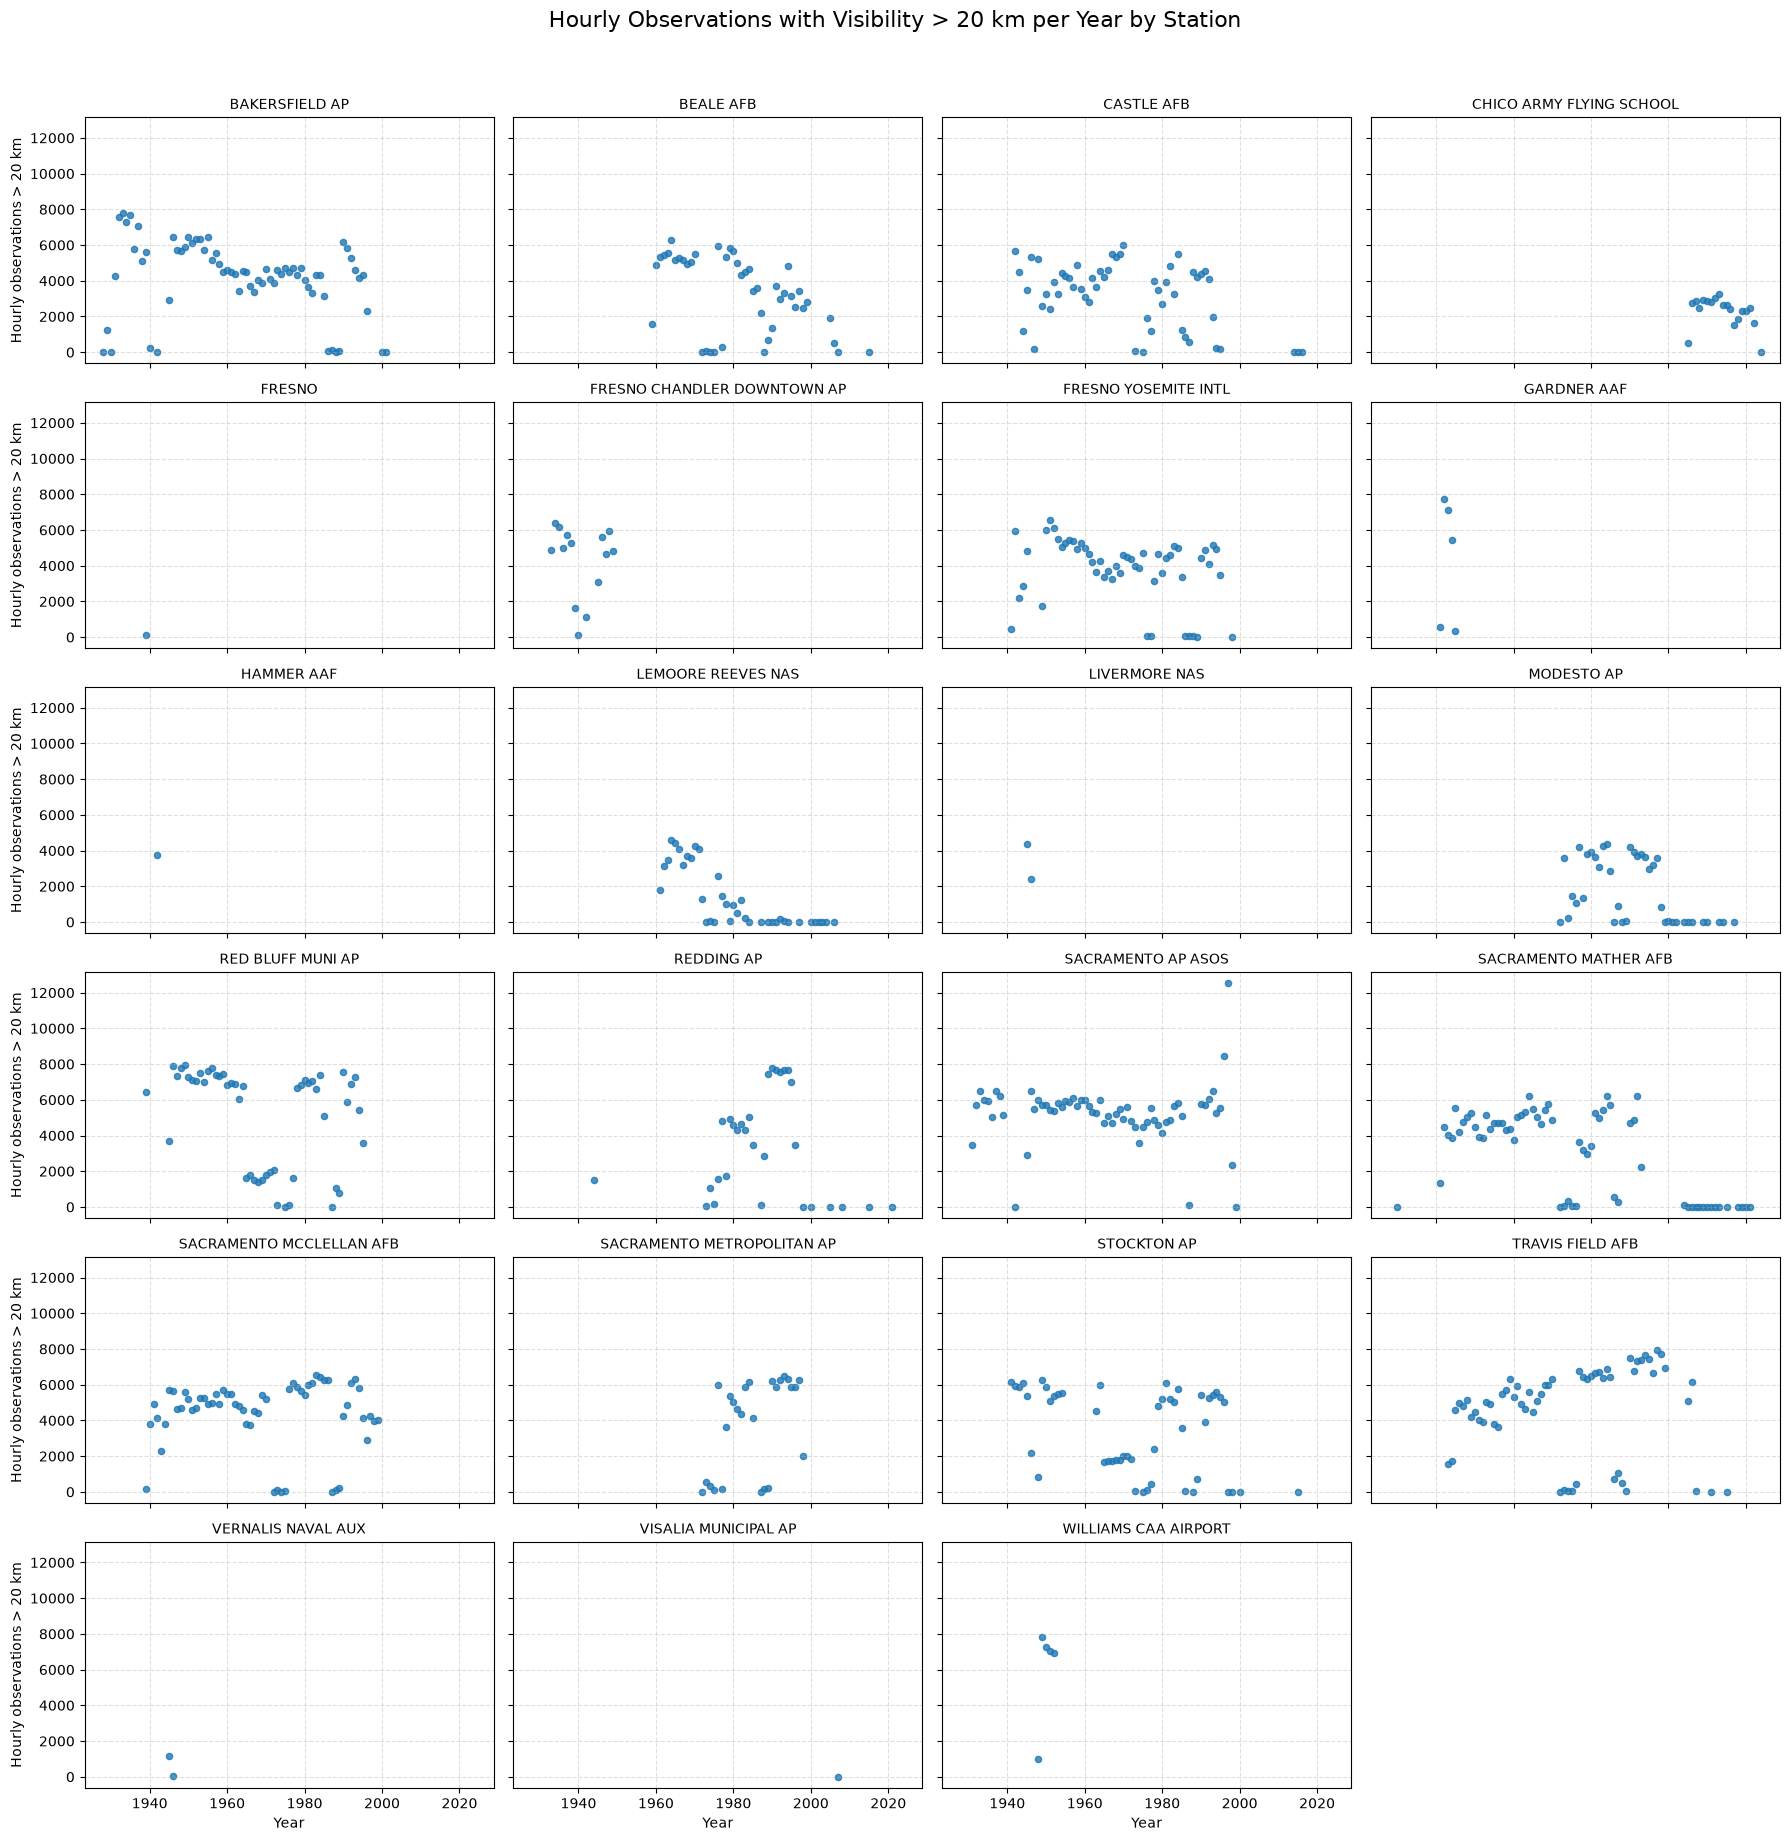

In [20]:
# Plot counters over 20 per station per year
stations = counts_over_20['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = counts_over_20[counts_over_20['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['count_over_20'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Hourly observations > 20 km')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Hourly Observations with Visibility > 20 km per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Count hourly observations per station-year with HourlyVisibility > 17 km
# vis = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
mask3 = vis > 17.0

counts_over_17 = (
    CV_rows.loc[mask3, ["STATION", "year"]]
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "count_over_17"})
    .sort_values(["STATION", "year"])
)

print(counts_over_17.head())

          STATION  year  count_over_17
0  BAKERSFIELD AP  1928              1
1  BAKERSFIELD AP  1929           1242
2  BAKERSFIELD AP  1930              5
3  BAKERSFIELD AP  1931           4296
4  BAKERSFIELD AP  1932           7639


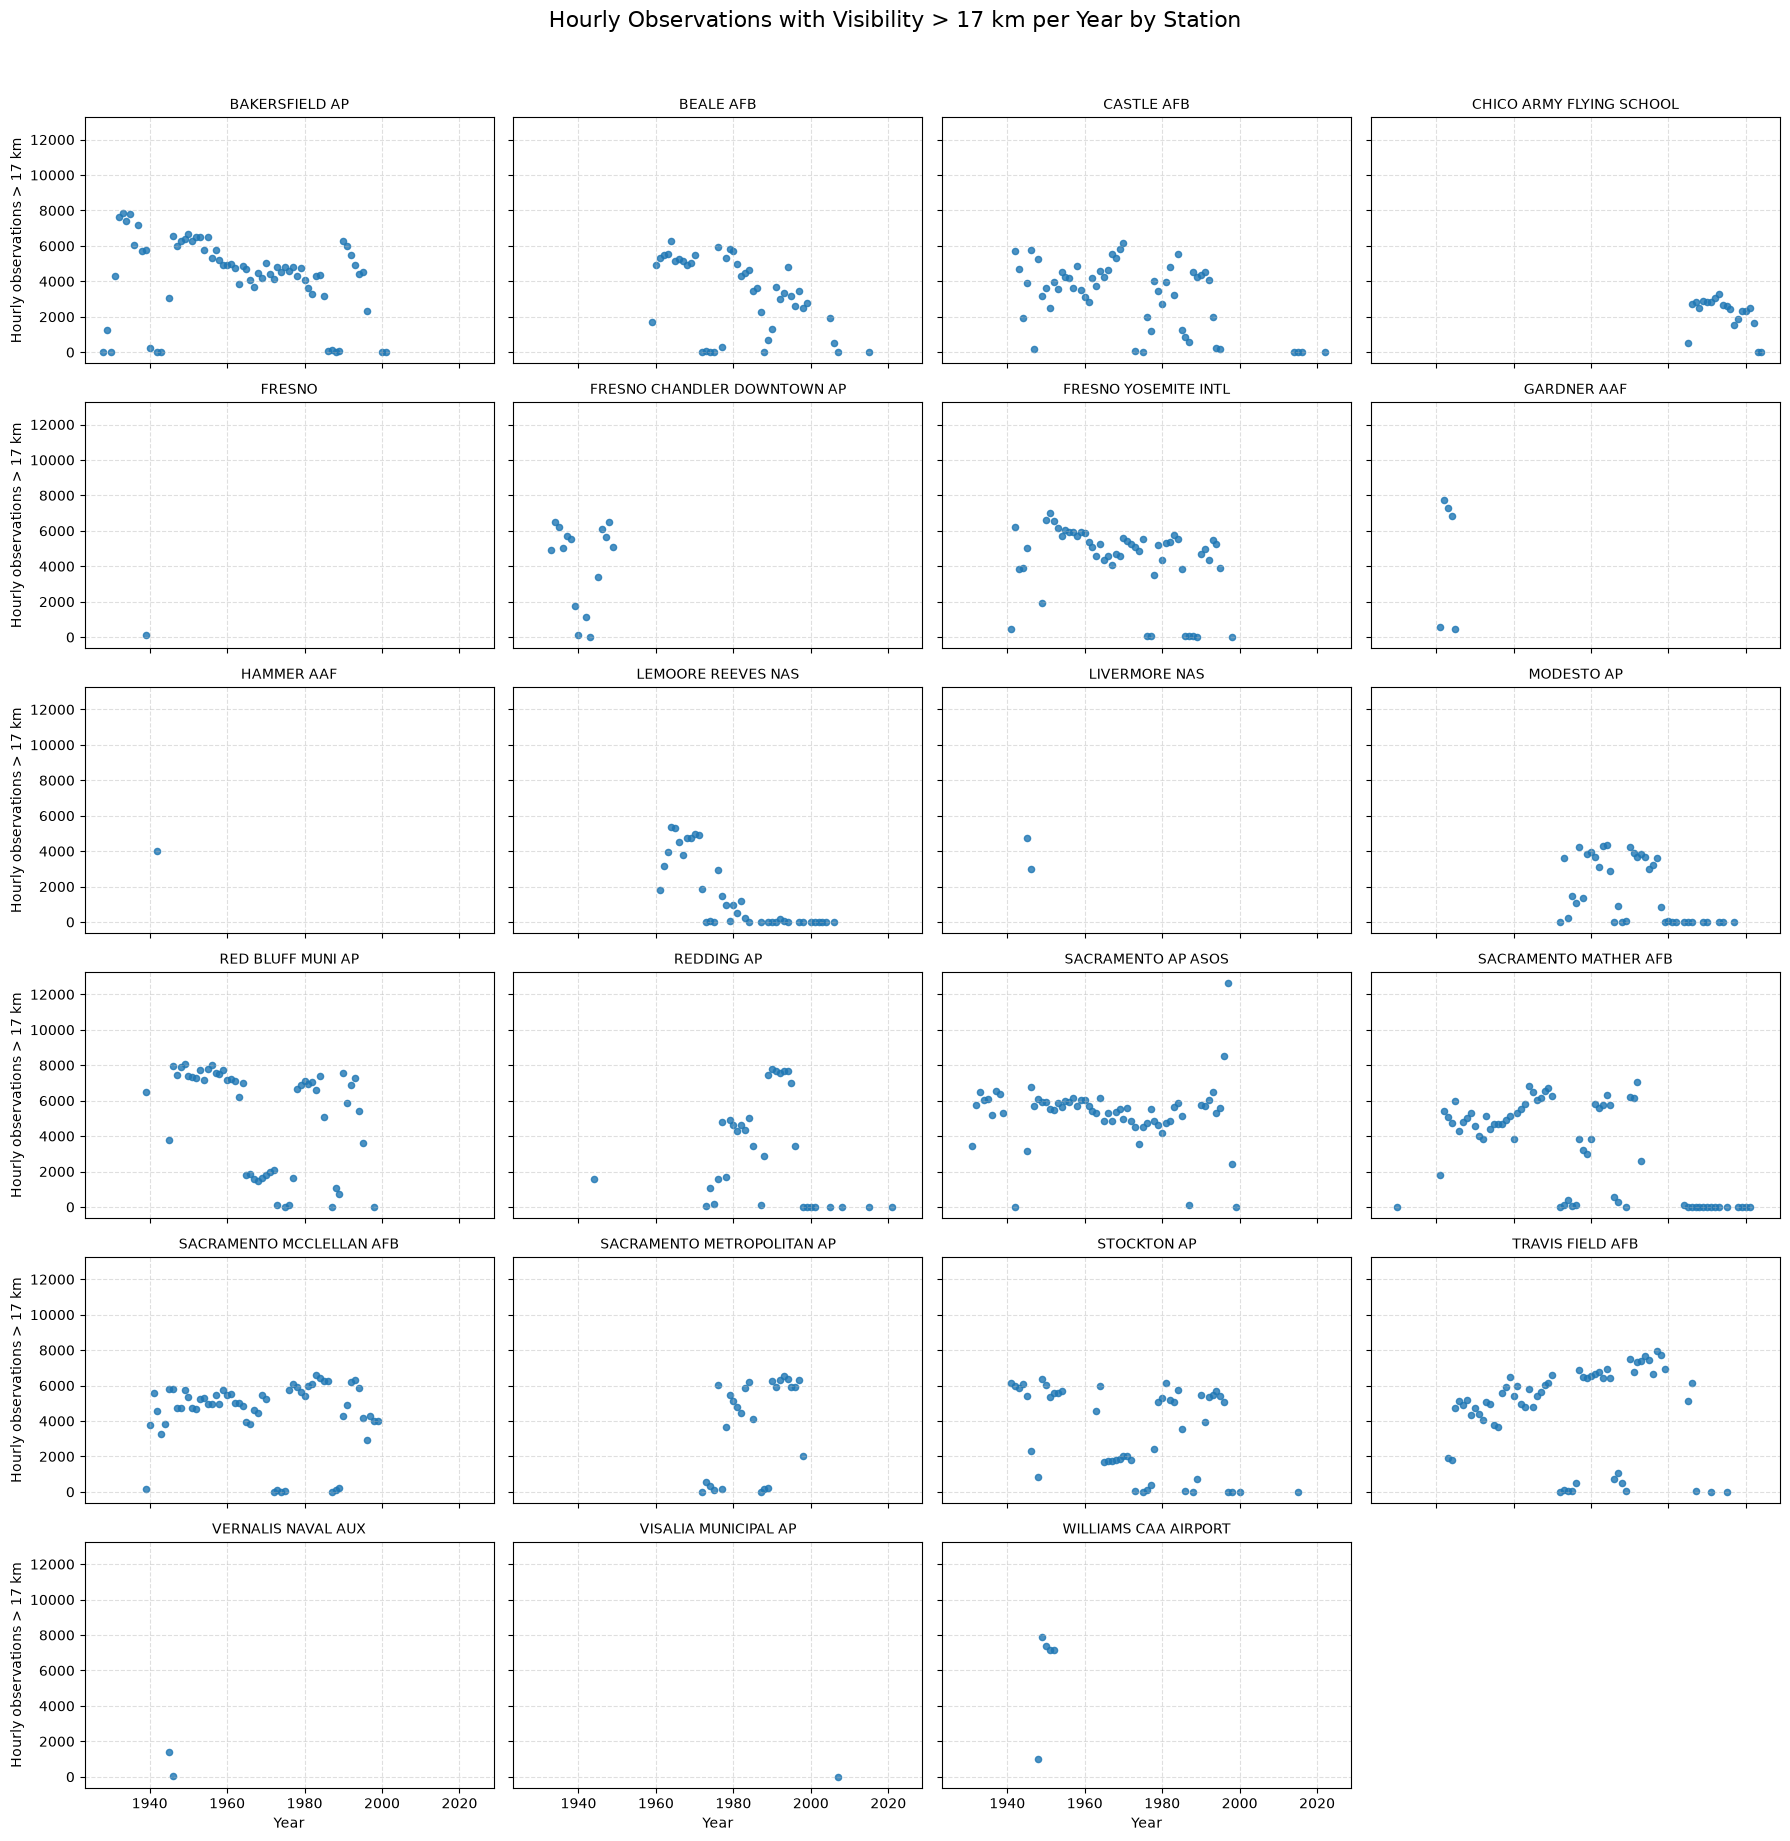

In [24]:
# Plot counters over 17 per station per year
stations = counts_over_17['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = counts_over_17[counts_over_17['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['count_over_17'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Hourly observations > 17 km')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Hourly Observations with Visibility > 17 km per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
# low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]

print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (189686, 12)


In [17]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [18]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (822, 3)


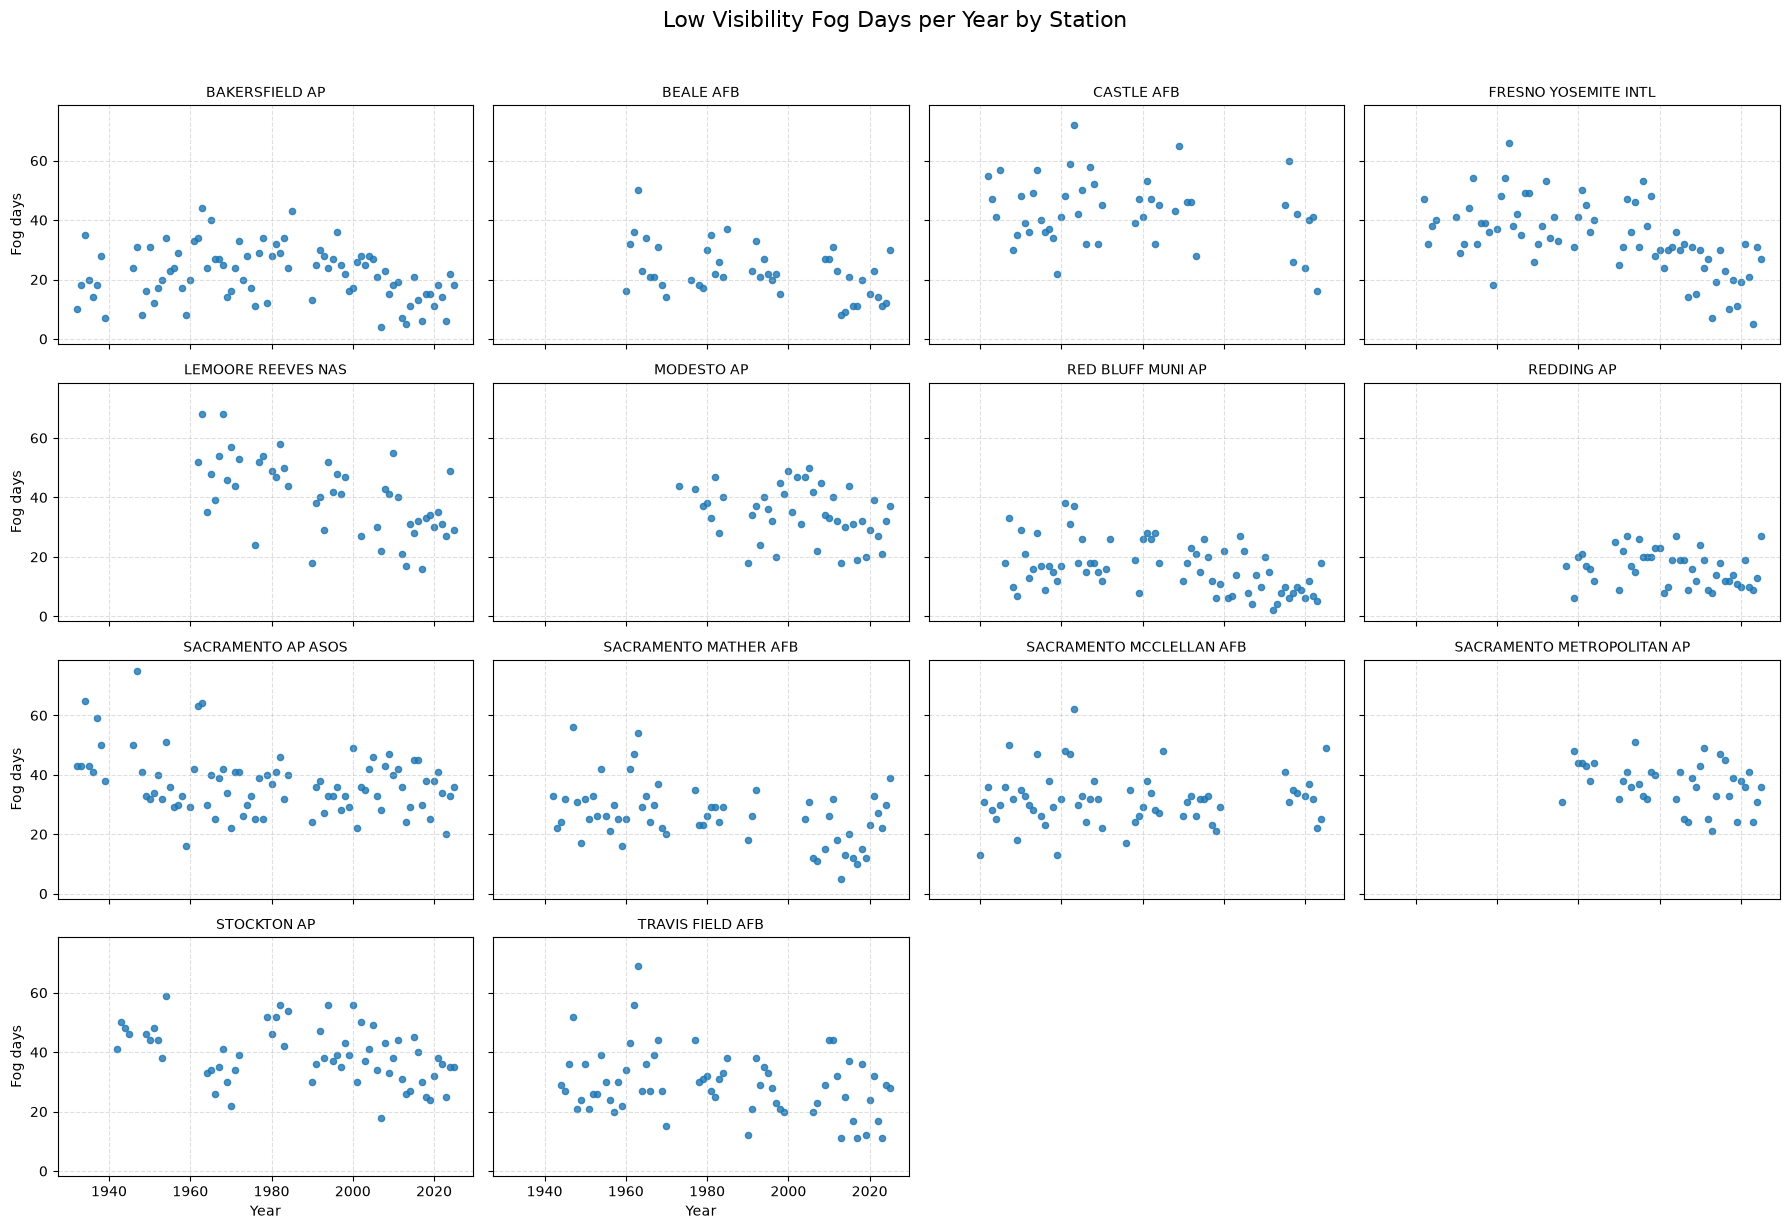

In [19]:
# plot the fog days per year for the filtered stations
stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

# set up the plot:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

# plotting for individual stations:
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [124]:
# trend_stats_low_vis = []

# for station, station_df in low_vis_fog_days_year.groupby("STATION"):
#     station_df = station_df.sort_values("year")
#     if len(station_df) < 3:
#         continue

#     model = smf.ols("fog_days ~ year", data=station_df).fit()

#     trend_stats_low_vis.append({
#         "STATION": station,
#         "n_obs": len(station_df),
#         "min_year": station_df["year"].min(),
#         "max_year": station_df["year"].max(),
#         "slope": model.params["year"],
#         "intercept": model.params["Intercept"],
#         "r_squared": model.rsquared,
#         "p_value": model.pvalues["year"],
#         "slope_se": model.bse["year"],
#         "trend_significant": model.pvalues["year"] < 0.05,
#     })

# trend_stats_low_vis = pd.DataFrame(trend_stats_low_vis).sort_values("p_value")

# print("Low-visibility fog-day trend statistics by station:")
# print(trend_stats_low_vis[
#     ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
# ].head(20))

# significant_low_vis = trend_stats_low_vis[trend_stats_low_vis["trend_significant"]]
# print(f"\nStations with significant low-visibility fog-day trends: {len(significant_low_vis)}")
# print(significant_low_vis[
#     ["STATION", "n_obs", "slope", "p_value", "r_squared"]
# ])

# annual_low_vis = (
#     low_vis_fog_days_year
#     .groupby("year", as_index=False)["fog_days"]
#     .sum()
# )

# model_annual_low_vis = smf.ols("fog_days ~ year", data=annual_low_vis).fit()

# print("\nAnnual aggregated low-visibility fog-day trend summary:")
# print(model_annual_low_vis.summary())

In [20]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.462137  0.078025   
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.616593  0.103746   
6            RED BLUFF MUNI AP     40      1980      2024 -0.399802  0.074850   
12                 STOCKTON AP     41      1980      2025 -0.406602  0.096144   
1                    BEALE AFB     30      1980      2025 -0.285823  0.082938   
4           LEMOORE REEVES NAS     35      1980      2025 -0.386315  0.121131   
7                   REDDING AP     42      1980      2025 -0.145064  0.067015   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.186481  0.087151   
2                   CASTLE AFB     18      1980      2023 -0.266627  0.166796   
5                   MODESTO AP     41      1980      2025 -0.153480  0.109553   
13            TRAVIS FIELD AFB     35      1980

In [21]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB', 'LEMOORE REEVES NAS', 'REDDING AP', 'SACRAMENTO METROPOLITAN AP']


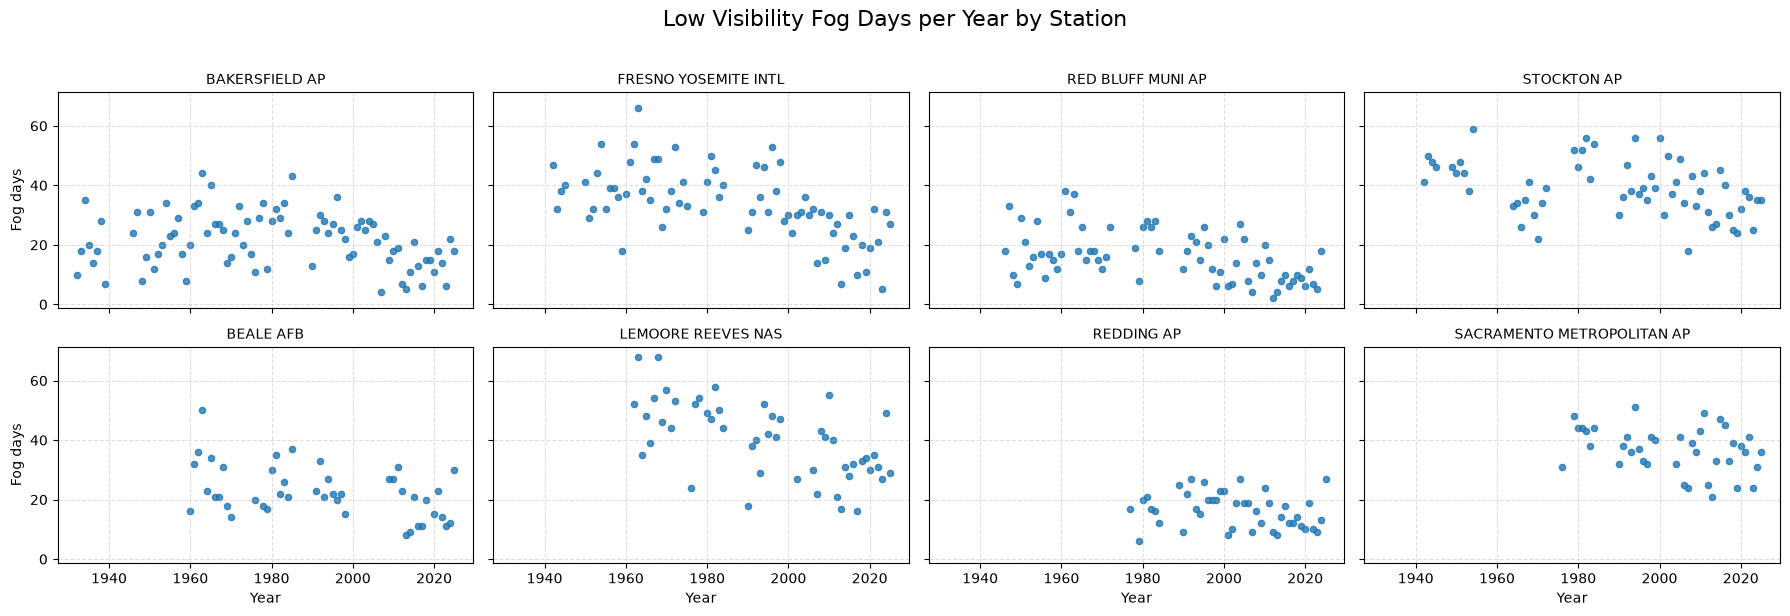

In [22]:
# Plot fog days per year for each station with significant trends post-1980
# for all years with data
stations = stations_significant_low_vis_post1980
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

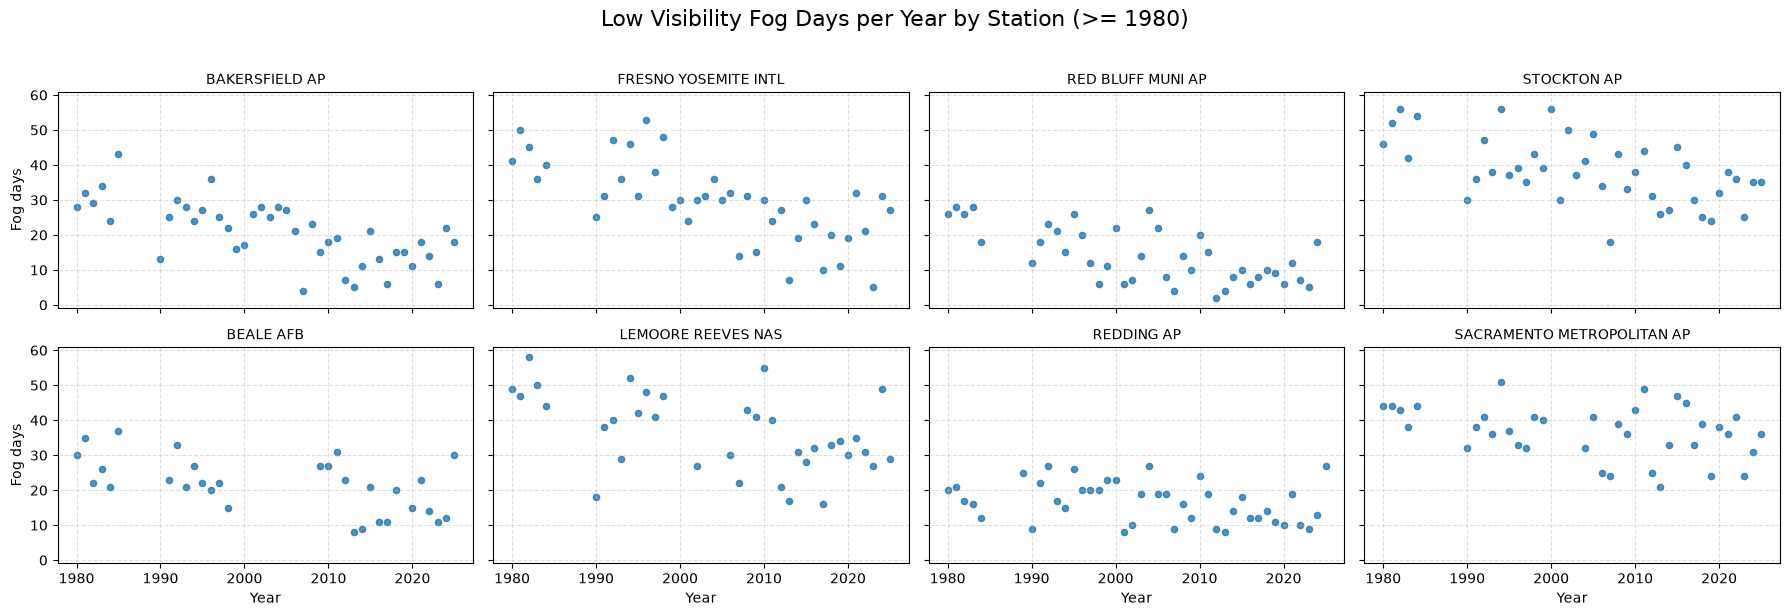

In [23]:
# Plot fog days per year for each station with significant trends post-1980
# for years post-1980
stations = stations_significant_low_vis_post1980

plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] >= 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (>= 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Filter for low visibility fog days pre-1980
pre1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] <= 1980].copy()

trend_stats_low_vis_pre1980 = []

for station, station_df in pre1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_pre1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_pre1980 = pd.DataFrame(trend_stats_low_vis_pre1980).sort_values("p_value")

print("Pre-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_pre1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_pre1980 = trend_stats_low_vis_pre1980[trend_stats_low_vis_pre1980["trend_significant"]]
print(f"\nStations with significant pre-1980 low-visibility fog-day trends: {len(significant_low_vis_pre1980)}")
print(significant_low_vis_pre1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_pre1980 = (
    pre1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_pre1980 = smf.ols("fog_days ~ year", data=annual_low_vis_pre1980).fit()

print("\nAnnual aggregated pre-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_pre1980.summary())

Pre-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
8           SACRAMENTO AP ASOS     43      1932      1980 -0.364501  0.121861   
12                 STOCKTON AP     21      1942      1980 -0.299436  0.156609   
5                   MODESTO AP      4      1973      1980 -0.991304  0.390046   
1                    BEALE AFB     15      1960      1980 -0.544709  0.377102   
0               BAKERSFIELD AP     43      1932      1980  0.134297  0.097285   
11  SACRAMENTO METROPOLITAN AP      3      1976      1980  3.807692  1.931903   
13            TRAVIS FIELD AFB     31      1944      1980  0.138514  0.203792   
4           LEMOORE REEVES NAS     15      1962      1980 -0.355957  0.544426   
9        SACRAMENTO MATHER AFB     32      1942      1980 -0.081734  0.162306   
10    SACRAMENTO MCCLELLAN AFB     36      1940      1980 -0.025403  0.150586   
2                   CASTLE AFB     30      1942 

In [25]:
# make a list of stations with significant pre-1980 low visibility trends
stations_significant_low_vis_pre1980 = significant_low_vis_pre1980.loc[
    significant_low_vis_pre1980["trend_significant"], "STATION"
].tolist()

print("Significant pre-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_pre1980)

Significant pre-1980 low-visibility fog-day trend stations:
['SACRAMENTO AP ASOS']


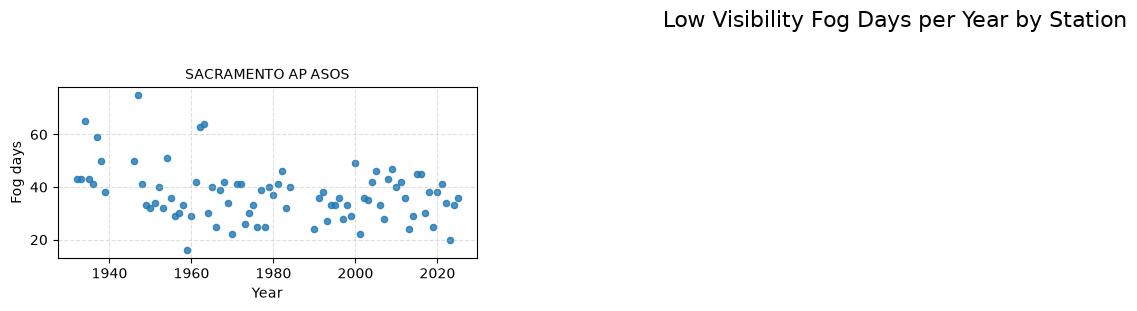

In [26]:
# Plot fog days per year for each station with significant trends pre-1980
# for all years with data
stations = stations_significant_low_vis_pre1980
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

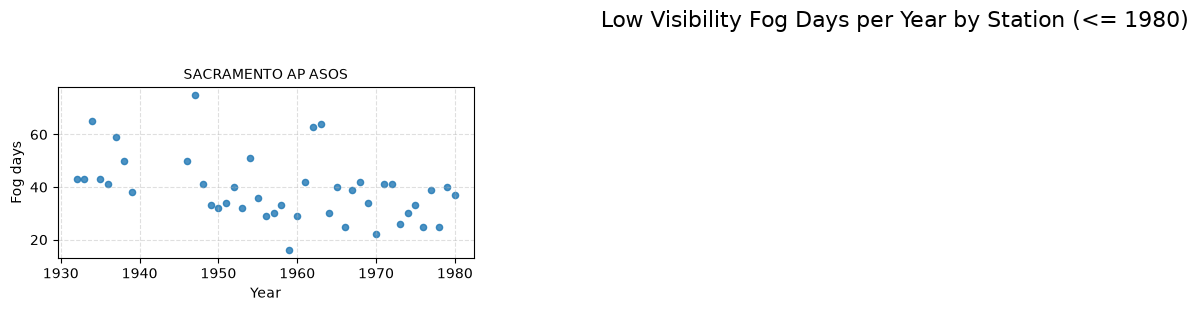

In [27]:
# Plot fog days per year for each station with significant trends pre-1980
# for only years pre-1980
stations = stations_significant_low_vis_pre1980

plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] <= 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (<= 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [155]:
# # compute low-visibility fog events from hourly CV_rows observations
# low_vis_events = low_vis_rows.copy()
# if low_vis_events["DATE"].dtype == object:
#     low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

# low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# # ensure DATE is datetime (handles object, pandas string dtype, etc.)
# if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
#     low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# # compute time difference within each station; treat first obs as a large gap
# low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
# low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
# low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
# low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# event_summary = (
#     low_vis_events
#     .groupby(["STATION", "event_id"], as_index=False)
#     .agg(
#         start=("DATE", "min"),
#         end=("DATE", "max"),
#         year=("year", "first"),
#         month=("month", "first"),
#         duration_hours=("event_id", "size"),
#     )
# )

# event_summary["year_month"] = pd.to_datetime(
#     dict(year=event_summary["year"], month=event_summary["month"], day=1)
# )

# monthly_low_vis_days = (
#     low_vis_events
#     .drop_duplicates(subset=["STATION", "year", "month", "day"])
#     .groupby(["STATION", "year", "month"], as_index=False)
#     .size()
#     .rename(columns={"size": "low_vis_days"})
# )

# event_monthly = (
#     event_summary
#     .groupby(["STATION", "year", "month"], as_index=False)
#     .agg(
#         avg_event_duration_hours=("duration_hours", "mean"),
#         n_events=("duration_hours", "size"),
#     )
#     .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
# )

# event_monthly["year_month"] = pd.to_datetime(
#     dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
# )

# annual_event_stats = (
#     event_monthly
#     .groupby(["STATION", "year"], as_index=False)
#     .agg(
#         avg_event_duration_hours=("avg_event_duration_hours", "mean"),
#         total_events=("n_events", "sum"),
#         avg_monthly_low_vis_days=("low_vis_days", "mean"),
#     )
# )

# annual_compare = low_vis_fog_days_year.merge(
#     annual_event_stats,
#     on=["STATION", "year"],
#     how="left"
# )

# print(annual_compare.head())


In [154]:
# # only using stations with long records
# # plot the average event duration vs total number events per station for each year
# # each data point is color coded by year
# stations = stations_with_30_years.tolist()
# plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
#     if station_df.empty:
#         ax.set_visible(False)
#         continue

#     sc = ax.scatter(
#         station_df["total_events"],
#         station_df["avg_event_duration_hours"],
#         c=station_df["year"],
#         cmap="viridis",
#         s=40,
#         alpha=0.8,
#         edgecolor="k",
#         linewidth=0.2,
#     )
#     ax.set_title(station, fontsize=10)
#     ax.set_xlabel("Total events")
#     if idx % ncols == 0:
#         ax.set_ylabel("Avg event duration (h)")
#     ax.grid(True, alpha=0.4)

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # setting color bar [left, bottom, width, height]

# cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", fraction=0.02, pad=0.02)
# cbar.set_label("Year")

# fig.suptitle("Average Event Duration vs Total Number of Events by Station", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

In [153]:
# stations = stations_with_30_years.tolist()
# plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

# year_min = plot_df["year"].min()
# year_max = plot_df["year"].max()
# norm = plt.Normalize(year_min, year_max)
# cmap = plt.cm.viridis

# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# sc = None
# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_ann = plot_df[
#         (plot_df["STATION"] == station) &
#         plot_df["avg_event_duration_hours"].notna()
#     ].sort_values("year")

#     if station_ann.empty:
#         ax.set_visible(False)
#         continue

#     sc = ax.scatter(
#         station_ann["fog_days"],
#         station_ann["avg_event_duration_hours"],
#         c=station_ann["year"],
#         cmap=cmap,
#         norm=norm,
#         s=40,
#         alpha=0.8,
#         edgecolor="k",
#         linewidth=0.2,
#     )
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle="--", alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel("Avg event duration (h)")
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel("Annual low-vis fog days")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# if sc is not None:
#     cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # [left, bottom, width, height]
#     cbar = fig.colorbar(sc, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
#     cbar.set_label("Year")

# fig.suptitle("Average Event Duration vs Annual Low-Visibility Fog Days by Station", y=1.02, fontsize=14)
# plt.tight_layout()
# plt.show()

In [152]:
# stations = stations_with_30_years.tolist()
# plot_df = annual_compare[
#     (annual_compare["year"] > 2000) &
#     (annual_compare["STATION"].isin(stations))
# ].copy()

# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = plot_df[
#         (plot_df["STATION"] == station) &
#         (plot_df["avg_event_duration_hours"].notna())
#     ].sort_values("year")

#     if station_df.empty:
#         ax.set_visible(False)
#         continue

#     ax.plot(
#         station_df["year"],
#         station_df["avg_event_duration_hours"],
#         marker="o",
#         linestyle="-",
#         markersize=4,
#         alpha=0.8,
#         linewidth=1
#     )
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle="--", alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel("Avg event duration (h)")
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel("Year")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle("Average Fog Event Duration per Year by Station (Post-2000)", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

In [151]:
# plot_df = annual_compare[
#     (annual_compare["year"] >= 1980) &
#     (annual_compare["STATION"].isin(stations_with_30_years))
# ].copy()

# stations = plot_df["STATION"].unique().tolist()
# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = plot_df[
#         (plot_df["STATION"] == station) &
#         (plot_df["avg_event_duration_hours"].notna())
#     ].sort_values("year")
#     if station_df.empty:
#         ax.set_visible(False)
#         continue

#     ax.plot(
#         station_df["year"],
#         station_df["avg_event_duration_hours"],
#         marker="o",
#         linestyle="None",
#         markersize=4,
#         alpha=0.8,
#         linewidth=1
#     )
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle="--", alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel("Avg event duration (h)")
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel("Year")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle("Average Fog Event Duration per Year by Station (≥ 1980)", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

In [150]:
# plot_df = annual_compare[
#     (annual_compare["year"] <= 1980) &
#     (annual_compare["STATION"].isin(stations_with_30_years))
# ].copy()

# stations = plot_df["STATION"].unique().tolist()
# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = plot_df[
#         (plot_df["STATION"] == station) &
#         (plot_df["avg_event_duration_hours"].notna())
#     ].sort_values("year")
#     if station_df.empty:
#         ax.set_visible(False)
#         continue

#     ax.plot(
#         station_df["year"],
#         station_df["avg_event_duration_hours"],
#         marker="o",
#         linestyle="None",
#         markersize=4,
#         alpha=0.8,
#         linewidth=1
#     )
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle="--", alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel("Avg event duration (h)")
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel("Year")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle("Average Fog Event Duration per Year by Station (<= 1980)", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

In [149]:
# # Plot low-visibility fog days per year by station, only for years after 1980
# stations = stations_with_30_years.tolist()
# plot_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] > 1980].copy()

# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
#     if station_df.empty:
#         ax.set_visible(False)
#         continue

#     ax.plot(
#         station_df["year"],
#         station_df["fog_days"],
#         marker="o",
#         linestyle="None",
#         markersize=4,
#         alpha=0.7,
#         linewidth=1
#     )
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle="--", alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel("Low-visibility fog days")
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel("Year")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle("Low-Visibility Fog Days per Year by Station (Post-1980)", fontsize=14, y=1.00)
# plt.tight_layout()
# plt.show()

In [148]:
# events_monthly = event_monthly.copy()
# events_monthly["year"] = events_monthly["year"].astype(int)

# def compute_station_monthly_trends(df, min_records=36):
#     rows = []
#     for station, g in df.groupby("STATION"):
#         g = g.sort_values("year_month")
#         if len(g) < min_records:
#             continue
#         model = smf.ols("n_events ~ year + C(month)", data=g).fit()
#         rows.append({
#             "STATION": station,
#             "n_obs": len(g),
#             "min_year": int(g["year"].min()),
#             "max_year": int(g["year"].max()),
#             "slope": model.params.get("year", np.nan),
#             "slope_se": model.bse.get("year", np.nan),
#             "p_value": model.pvalues.get("year", np.nan),
#             "r_squared": model.rsquared,
#             "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
#         })
#     return pd.DataFrame(rows).sort_values(["trend_significant", "p_value"])

# events_pre1980 = events_monthly[events_monthly["year"] < 1980]
# events_post1980 = events_monthly[events_monthly["year"] >= 1980]

# trend_pre1980 = compute_station_monthly_trends(events_pre1980)
# trend_post1980 = compute_station_monthly_trends(events_post1980)

# trend_compare = (
#     trend_pre1980.set_index("STATION")
#     .join(trend_post1980.set_index("STATION"), lsuffix="_pre", rsuffix="_post", how="inner")
#     .reset_index()
# )
# trend_compare["slope_change"] = trend_compare["slope_post"] - trend_compare["slope_pre"]
# trend_compare["slope_change_pct"] = np.where(
#     trend_compare["slope_pre"].ne(0),
#     100 * trend_compare["slope_change"] / trend_compare["slope_pre"].abs(),
#     np.nan,
# )

# print("Pre-1980 monthly-event trends")
# print(trend_pre1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
# print(f"\nPre-1980 stations with significant trends: {trend_pre1980['trend_significant'].sum()}/{len(trend_pre1980)}")

# print("\nPost-1980 monthly-event trends")
# print(trend_post1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
# print(f"\nPost-1980 stations with significant trends: {trend_post1980['trend_significant'].sum()}/{len(trend_post1980)}")

# print(f"\nStations with both pre-1980 and post-1980 trend estimates: {len(trend_compare)}")
# display_cols = [
#     "STATION",
#     "slope_pre",
#     "p_value_pre",
#     "trend_significant_pre",
#     "slope_post",
#     "p_value_post",
#     "trend_significant_post",
#     "slope_change",
#     "slope_change_pct",
# ]
# print(trend_compare[display_cols].sort_values("p_value_post").reset_index(drop=True))

# common_stations = trend_compare["STATION"].tolist()
# if common_stations:
#     fig, ax = plt.subplots(figsize=(max(12, len(common_stations) * 0.7), 6))
#     x = np.arange(len(common_stations))
#     width = 0.35

#     ax.bar(x - width / 2, trend_compare["slope_pre"], width, label="pre-1980", alpha=0.7)
#     ax.bar(x + width / 2, trend_compare["slope_post"], width, label="post-1980", alpha=0.7)
#     ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)

#     ax.set_xticks(x)
#     ax.set_xticklabels(common_stations, rotation=45, ha="right", fontsize=9)
#     ax.set_ylabel("Slope (n_events per year)")
#     ax.set_title("Monthly fog-event trend slopes before and after 1980 by station")
#     ax.legend()
#     plt.tight_layout()
#     plt.show()

In [147]:
# station_years_no_outliers = fog_days_year_no_outliers[["STATION", "year"]].drop_duplicates()

# low_vis_fog_days_year_no_outliers = low_vis_fog_days_year.merge(
#     station_years_no_outliers, on=["STATION", "year"], how="inner"
# )

# event_monthly_no_outliers = event_monthly.merge(
#     station_years_no_outliers, on=["STATION", "year"], how="inner"
# )

# annual_compare_no_outliers = annual_compare.merge(
#     station_years_no_outliers, on=["STATION", "year"], how="inner"
# )

# station_year_counts_no_outliers = low_vis_fog_days_year_no_outliers.groupby("STATION")["year"].nunique()
# stations_with_30_years_no_outliers = station_year_counts_no_outliers[
#     station_year_counts_no_outliers >= 30
# ].index.tolist()

# print("Filtered station-years:", station_years_no_outliers.shape[0])
# print("low_vis_fog_days_year_no_outliers:", low_vis_fog_days_year_no_outliers.shape)
# print("event_monthly_no_outliers:", event_monthly_no_outliers.shape)
# print("annual_compare_no_outliers:", annual_compare_no_outliers.shape)
# print("Stations with >= 30 years:", len(stations_with_30_years_no_outliers))

# trend_stats_events_monthly_no_outliers = []
# for station, df in event_monthly_no_outliers.groupby("STATION"):
#     df = df.sort_values("year_month")
#     if len(df) < 36:
#         continue
#     model = smf.ols("n_events ~ year + C(month)", data=df).fit()
#     trend_stats_events_monthly_no_outliers.append({
#         "STATION": station,
#         "n_obs": len(df),
#         "min_year": int(df["year"].min()),
#         "max_year": int(df["year"].max()),
#         "slope": model.params.get("year", np.nan),
#         "slope_se": model.bse.get("year", np.nan),
#         "p_value": model.pvalues.get("year", np.nan),
#         "r_squared": model.rsquared,
#         "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
#     })

# trend_stats_events_monthly_no_outliers = pd.DataFrame(trend_stats_events_monthly_no_outliers).sort_values("p_value")

# print("\nMonthly-event trend statistics by station (restricted years):")
# print(trend_stats_events_monthly_no_outliers.head(20))

# significant_events_monthly_no_outliers = trend_stats_events_monthly_no_outliers[
#     trend_stats_events_monthly_no_outliers["trend_significant"]
# ]
# print(f"\nStations with significant monthly-event trends (restricted years): {len(significant_events_monthly_no_outliers)}")
# print(significant_events_monthly_no_outliers[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# events_post1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] >= 1980].copy()
# events_pre1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] < 1980].copy()

# def compute_trends(df):
#     stats = []
#     for station, g in df.groupby("STATION"):
#         g = g.sort_values("year_month")
#         if len(g) < 36:
#             continue
#         model = smf.ols("n_events ~ year + C(month)", data=g).fit()
#         stats.append({
#             "STATION": station,
#             "n_obs": len(g),
#             "min_year": int(g["year"].min()),
#             "max_year": int(g["year"].max()),
#             "slope": model.params.get("year", np.nan),
#             "slope_se": model.bse.get("year", np.nan),
#             "p_value": model.pvalues.get("year", np.nan),
#             "r_squared": model.rsquared,
#             "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
#         })
#     return pd.DataFrame(stats).sort_values("p_value")

# trend_events_post1980_no_outliers = compute_trends(events_post1980_no_outliers)
# trend_events_pre1980_no_outliers = compute_trends(events_pre1980_no_outliers)

# print("\nPost-1980 monthly-event trends (restricted years, top 20):")
# print(trend_events_post1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# print("\nPre-1980 monthly-event trends (restricted years, top 20):")
# print(trend_events_pre1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# annual_events_no_outliers = event_monthly_no_outliers.groupby(
#     ["STATION", "year"], as_index=False
# )["n_events"].sum().rename(columns={"n_events": "annual_n_events"})
# print("\nAnnual events (restricted years, sample):")
# print(annual_events_no_outliers.head())


In [146]:
# # Monthly-event analysis: trends of fog events per month-year by station

# # use existing event_monthly (has n_events, avg_event_duration_hours, year, month, year_month)
# events_monthly = event_monthly.copy()
# events_monthly["year"] = events_monthly["year"].astype(int)

# # station-level trends (model n_events ~ year + C(month) to account for seasonality)
# trend_stats_events_monthly = []
# for station, df in events_monthly.groupby("STATION"):
#     df = df.sort_values("year_month")
#     if len(df) < 36:  # require at least 3 years of monthly data
#         continue
#     model = smf.ols("n_events ~ year + C(month)", data=df).fit()
#     trend_stats_events_monthly.append({
#         "STATION": station,
#         "n_obs": len(df),
#         "min_year": df["year"].min(),
#         "max_year": df["year"].max(),
#         "slope": model.params.get("year", np.nan),
#         "slope_se": model.bse.get("year", np.nan),
#         "p_value": model.pvalues.get("year", np.nan),
#         "r_squared": model.rsquared,
#         "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
#     })

# trend_stats_events_monthly = pd.DataFrame(trend_stats_events_monthly).sort_values("p_value")
# print("Monthly-event trend statistics by station (n_events ~ year + month):")
# print(trend_stats_events_monthly.head(20))

# significant_events_monthly = trend_stats_events_monthly[trend_stats_events_monthly["trend_significant"]]
# print(f"\nStations with significant monthly-event trends: {len(significant_events_monthly)}")
# print(significant_events_monthly[["STATION","n_obs","slope","p_value","r_squared"]])

# # Post-1980 and Pre-1980 splits
# events_post1980 = events_monthly[events_monthly["year"] >= 1980].copy()
# events_pre1980 = events_monthly[events_monthly["year"] < 1980].copy()

# def compute_trends(df):
#     stats = []
#     for station, g in df.groupby("STATION"):
#         g = g.sort_values("year_month")
#         if len(g) < 36:
#             continue
#         model = smf.ols("n_events ~ year + C(month)", data=g).fit()
#         stats.append({
#             "STATION": station,
#             "n_obs": len(g),
#             "min_year": g["year"].min(),
#             "max_year": g["year"].max(),
#             "slope": model.params.get("year", np.nan),
#             "slope_se": model.bse.get("year", np.nan),
#             "p_value": model.pvalues.get("year", np.nan),
#             "r_squared": model.rsquared,
#             "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
#         })
#     return pd.DataFrame(stats).sort_values("p_value")

# trend_events_post1980 = compute_trends(events_post1980)
# trend_events_pre1980 = compute_trends(events_pre1980)

# print("\nPost-1980 monthly-event trends (top 20):")
# print(trend_events_post1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

# print("\nPre-1980 monthly-event trends (top 20):")
# print(trend_events_pre1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

# # Aggregate annual-seasonal diagnostics:
# # annual sum of monthly events per station-year
# annual_events = events_monthly.groupby(["STATION","year"], as_index=False)["n_events"].sum().rename(columns={"n_events":"annual_n_events"})
# print("\nAnnual events (sample):")
# print(annual_events.head())

# # Plot: time series of monthly event counts for stations_with_30_years
# plot_stations = stations_with_30_years.tolist()
# n_stations = len(plot_stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.8), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(plot_stations):
#     ax = axes[idx]
#     sdf = events_monthly[events_monthly["STATION"] == station].sort_values("year_month")
#     if sdf.empty:
#         ax.set_visible(False)
#         continue
#     ax.plot(sdf["year_month"], sdf["n_events"], marker='o', linestyle='-', markersize=3, alpha=0.7)
#     ax.set_title(station, fontsize=9)
#     ax.grid(True, alpha=0.4)
#     if idx % ncols == 0:
#         ax.set_ylabel("Monthly n_events")
#     if idx >= (nrows-1)*ncols:
#         ax.set_xlabel("Year-month")

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle("Monthly Fog Events per Month-Year by Station", y=1.02, fontsize=14)
# plt.tight_layout()
# plt.show()

In [145]:
# # Create a comprehensive plot of low-visibility fog days per station per year
# stations = stations_with_30_years.tolist()
# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station].sort_values('year')
#     ax.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-', markersize=4, alpha=0.7, linewidth=1)
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle='--', alpha=0.4)
    
#     if idx % ncols == 0:
#         ax.set_ylabel('Low-visibility fog days')
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel('Year')

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle('Low-Visibility Fog Days per Year by Station', fontsize=14, y=1.00)
# plt.tight_layout()
# plt.show()